# Initial Testing

### Testing Approximate FAISS using IndexIVFPQ

In [ ]:
import pandas as pd
import numpy as np
import faiss
import json
import os

def load_embeddings_from_parquet(parquet_path, embedding_column="embeddings_result", id_column="original_image_index", limit=None):
    """
    Load embeddings and IDs from a Parquet file.
    Optionally limit to the first `limit` rows.
    """
    df = pd.read_parquet(parquet_path)
    
    # Keep only rows with valid embeddings
    df = df[df[embedding_column].notnull()].copy()
    
    # Optionally limit number of rows
    if limit:
        df = df.head(limit)
    
    # Convert embeddings to numpy array
    embeddings = np.stack(df[embedding_column].values).astype(np.float32)
    ids = df[id_column].values
    
    return embeddings, ids

def find_duplicates_ivfpq(embeddings, ids=None, nlist=1024, m=16, nprobe=8, k=5, threshold=0.90, use_gpu=True):
    """
    Find duplicates using FAISS IVF+PQ (approximate search).
    """
    N, D = embeddings.shape
    print(f"Indexing {N} embeddings of dimension {D} with IVF+PQ...")

    # Normalize embeddings for cosine similarity
    faiss.normalize_L2(embeddings)

    # Build IVF+PQ index
    quantizer = faiss.IndexFlatIP(D)
    index = faiss.IndexIVFPQ(quantizer, D, nlist, m, 8)  # 8 bits per subvector

    # Train the index on embeddings
    train_size = min(100000, N)
    print(f"Training IVF+PQ on {train_size} embeddings...")
    index.train(embeddings[:train_size])

    # Add all embeddings to the index
    index.add(embeddings)

    # GPU fallback
    if use_gpu:
        try:
            res = faiss.StandardGpuResources()
            index = faiss.index_cpu_to_gpu(res, 0, index)
            print("✅ Using FAISS GPU index")
        except AttributeError:
            print("⚠️ FAISS GPU not available, falling back to CPU")
            use_gpu = False

    # Set nprobe (number of clusters to search)
    index.nprobe = nprobe

    # Search for nearest neighbors
    distances, neighbors = index.search(embeddings, k)

    duplicates = []
    seen = set()
    for i in range(N):
        for j_idx in range(1, k):  # skip self-match
            j = neighbors[i, j_idx]
            sim = distances[i, j_idx]
            if sim >= threshold and (j, i) not in seen:
                seen.add((i, j))
                duplicates.append({
                    "image_id_1": int(ids[i]) if ids is not None else int(i),
                    "image_id_2": int(ids[j]) if ids is not None else int(j),
                    "similarity": float(sim)
                })

    print(f"Found {len(duplicates)} duplicate pairs.")
    return duplicates


parquet_file = parquet_file = "clip_embeddings_resumable_symlink/all_images_openai_clip_vit_large_patch14/0001_embeddings/part-00000-checkpoint-1236200.parquet"
output_dir = os.path.dirname(parquet_file)

# Limit to first 10,000 embeddings
embeddings, ids = load_embeddings_from_parquet(
    parquet_file,
    embedding_column="embeddings_result",
    limit=10000
)

duplicates = find_duplicates_ivfpq(
    embeddings,
    ids=ids,
    nlist=256,      # smaller nlist for testing
    m=16,
    nprobe=8,
    k=5,
    threshold=0.90,
    use_gpu=True
)

# Save duplicates to JSON
output_json = os.path.join(output_dir, os.path.basename(parquet_file).replace(".parquet", "_duplicates_ivfpq.json"))
with open(output_json, "w") as f:
    json.dump(duplicates, f, indent=2)

print(f"Duplicate results saved to: {output_json}")

### Testing Exact Search FAISS using IndexFlatIP

In [ ]:
import pandas as pd
import numpy as np
import faiss
import json
import os

def load_embeddings_from_parquet(parquet_path, embedding_column="embeddings_result", id_column="original_image_index"):
    """
    Load embeddings and IDs from a Parquet file.
    Assumes embeddings are stored as lists or arrays in 'embedding_column'.
    """
    df = pd.read_parquet(parquet_path)
    
    # Keep only rows with valid embeddings
    df = df[df[embedding_column].notnull()].copy()
    
    # Convert embeddings to numpy array
    embeddings = np.stack(df[embedding_column].values).astype(np.float32)
    ids = df[id_column].values
    
    return embeddings, ids

def find_duplicates_within_embeddings(embeddings, ids=None, k=5, threshold=0.90, use_gpu=True):
    """
    Find duplicate images within a single set of embeddings using FAISS.
    Automatically falls back to CPU if GPU FAISS is unavailable.
    """
    N, D = embeddings.shape
    print(f"Indexing {N} embeddings of dimension {D}...")

    # Normalize embeddings for cosine similarity
    faiss.normalize_L2(embeddings)

    # Build FAISS index
    index = faiss.IndexFlatIP(D)  # Inner product = cosine similarity for normalized vectors

    # GPU fallback
    if use_gpu:
        try:
            res = faiss.StandardGpuResources()
            index = faiss.index_cpu_to_gpu(res, 0, index)
            print("✅ Using FAISS GPU index")
        except AttributeError:
            print("⚠️ FAISS GPU not available, falling back to CPU")
            use_gpu = False

    index.add(embeddings)
    
    # Search nearest neighbors
    distances, neighbors = index.search(embeddings, k)

    duplicates = []
    seen = set()
    for i in range(N):
        for j_idx in range(1, k):  # skip self-match at j=0
            j = neighbors[i, j_idx]
            sim = distances[i, j_idx]
            if sim >= threshold and (j, i) not in seen:
                seen.add((i, j))
                duplicates.append({
                    "image_id_1": int(ids[i]) if ids is not None else int(i),
                    "image_id_2": int(ids[j]) if ids is not None else int(j),
                    "similarity": float(sim)
                })

    print(f"Found {len(duplicates)} duplicate pairs.")
    return duplicates

parquet_file = "clip_embeddings_resumable_symlink/all_images_openai_clip_vit_large_patch14/0001_embeddings/part-00000-checkpoint-1236200.parquet"

embeddings, ids = load_embeddings_from_parquet(parquet_file, embedding_column="embeddings_result")

duplicates = find_duplicates_within_embeddings(
    embeddings,
    ids=ids,
    k=5,          # number of neighbors to check
    threshold=0.90, # cosine similarity threshold
    use_gpu=True
)

# Save duplicates to JSON
output_json = parquet_file.replace(".parquet", "_duplicates.json")
with open(output_json, "w") as f:
    json.dump(duplicates, f, indent=2)

print(f"Duplicate results saved to: {output_json}")


In [ ]:
# fetch_image defined in CombinedFile.ipynb

import pandas as pd
import json
import matplotlib.pyplot as plt
from PIL import Image

def display_duplicate_pairs_from_parquet(parquet_file, duplicates_json, max_pairs=5):
    """
    Display duplicate pairs using URLs from the Parquet file.

    - parquet_file: Parquet containing 'url', 'caption', 'original_image_index'
    - duplicates_json: JSON file containing duplicate pairs
    - max_pairs: number of duplicate pairs to display
    """
    # Load Parquet
    df = pd.read_parquet(parquet_file)
    id_to_row = df.set_index("original_image_index").to_dict(orient="index")

    # Load duplicates JSON
    with open(duplicates_json, "r") as f:
        duplicates = json.load(f)

    for i, dup in enumerate(duplicates[:max_pairs]):
        id1 = dup["image_id_1"]
        id2 = dup["image_id_2"]
        sim = dup["similarity"]

        row1 = id_to_row.get(id1)
        row2 = id_to_row.get(id2)
        if row1 is None or row2 is None:
            print(f"⚠️ Missing data for IDs {id1}, {id2}")
            continue

        # Fetch images using your existing function
        _, url1, caption1, img1 = fetch_image((id1, row1))
        _, url2, caption2, img2 = fetch_image((id2, row2))

        if img1 is None or img2 is None:
            print(f"⚠️ Could not fetch images for IDs {id1}, {id2}")
            continue

        # Display side by side
        plt.figure(figsize=(8, 4))
        plt.suptitle(f"Duplicate Pair {i+1} | Similarity: {sim:.3f}")
        plt.subplot(1, 2, 1)
        plt.imshow(img1)
        plt.title(f"ID: {id1}\n{caption1[:50]}")
        plt.axis("off")
        plt.subplot(1, 2, 2)
        plt.imshow(img2)
        plt.title(f"ID: {id2}\n{caption2[:50]}")
        plt.axis("off")
        plt.show()

parquet_file = "clip_embeddings_resumable_symlink/all_images_openai_clip_vit_large_patch14/0001_embeddings/part-00000-checkpoint-1236200.parquet"
duplicates_json = "C:\\MastersRepos\\ARI5902-Research-Topics-in-AI\\LAION-5B Testing\\clip_embeddings_resumable_symlink\\all_images_openai_clip_vit_large_patch14\\0001_embeddings\\part-00000-checkpoint-1236200_duplicates_ivfpq.json"

display_duplicate_pairs_from_parquet(parquet_file, duplicates_json, max_pairs=5)

### Testing SSCD (Self-Supervised Copt Detection) Model for creating embeddings to derive duplicates

In [ ]:
import os
import glob
import time
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm
from PIL import Image
import requests
from io import BytesIO
import torch
import torch.nn as nn

# -----------------------------
# Download SSCD model if needed
# -----------------------------
SSCD_MODEL_URL = "https://dl.fbaipublicfiles.com/sscd-copy-detection/sscd_disc_mixup.torchscript.pt"
SSCD_MODEL_PATH = "models/sscd_disc_mixup.torchscript.pt"
os.makedirs("models", exist_ok=True)

if not os.path.exists(SSCD_MODEL_PATH):
    print("📥 Downloading SSCD model...")
    import urllib.request
    urllib.request.urlretrieve(SSCD_MODEL_URL, SSCD_MODEL_PATH)
    print("✅ SSCD model downloaded!")

# -----------------------------
# Define SSCD wrapper
# -----------------------------
class SSCDModel(nn.Module):
    def __init__(self, model_path):
        super().__init__()
        self.model = torch.jit.load(model_path)
        self.model.eval()

    def forward(self, images):
        # images should be a torch.Tensor [B,3,H,W] normalized to 0-1
        with torch.no_grad():
            return self.model(images)

# -----------------------------
# Image fetching
# -----------------------------
def fetch_image(index_row_tuple):
    index, row = index_row_tuple
    url = row["url"]
    caption = row.get("caption", "")
    try:
        resp = requests.get(url, timeout=10)
        resp.raise_for_status()
        img = Image.open(BytesIO(resp.content)).convert("RGB")
        return index, url, caption, img
    except:
        return index, url, caption, None

# -----------------------------
# Convert PIL images to tensor
# -----------------------------
def images_to_tensor(pil_images, size=(224,224), device="cpu"):
    if len(pil_images) == 0:
        return torch.empty((0, 3, size[0], size[1]), device=device)
    tensors = []
    for img in pil_images:
        img = img.resize(size)
        t = torch.tensor(np.array(img).transpose(2,0,1), dtype=torch.float32) / 255.0
        tensors.append(t)
    return torch.stack(tensors).to(device)


# -----------------------------
# Compute embeddings
# -----------------------------
def derive_embeddings(image_tuples, model, device="cpu"):
    """
    Convert a batch of (index, url, caption, image) tuples to embeddings using SSCD model.
    Skips any images that failed to download.
    """
    results = []

    # Filter out failed images
    valid_imgs = [(idx, url, cap, img) for idx, url, cap, img in image_tuples if img is not None]

    if len(valid_imgs) == 0:
        return []

    # Extract just the PIL images
    pil_images = [img for _, _, _, img in valid_imgs]

    # Convert to tensors
    img_tensor = images_to_tensor(pil_images, device=device)

    # Forward pass
    embeddings = model(img_tensor).cpu().numpy()

    for (idx, url, caption, _), emb in zip(valid_imgs, embeddings):
        results.append({
            "original_image_index": idx,
            "url": url,
            "caption": caption,
            "embeddings_result": emb.tolist()
        })

    return results
# -----------------------------
# Main processing function
# -----------------------------
def process_parquet_images_sscd(
    directory,
    parquet_file,
    output_base_dir,
    batch_size=200,
    number_of_workers=32,
    image_limit=None,
    save_interval=5000,
    dataset_split_size=50000,
    row_grp_size=50000,
):
    parquet_path = os.path.join(directory, parquet_file)
    print(f"📅 Loading DataFrame from {parquet_path}...")
    df = pd.read_parquet(parquet_path)
    if image_limit:
        df = df.head(image_limit)
    print(f"📊 Loaded {len(df)} images for processing.")

    # Output directory
    dataset_dir = os.path.join(output_base_dir, parquet_file.replace(".parquet","_sscd_embeddings"))
    os.makedirs(dataset_dir, exist_ok=True)

    # Load SSCD model
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = SSCDModel(SSCD_MODEL_PATH).to(device)

    buffer = []
    total_processed = 0
    split_index = 0

    for batch_start in tqdm(range(0, len(df), batch_size), desc="Processing Batches"):
        batch_end = min(batch_start + batch_size, len(df))
        batch_rows = list(df.iloc[batch_start:batch_end].iterrows())

        # Download images in parallel
        with ThreadPoolExecutor(max_workers=number_of_workers) as executor:
            fetched = list(executor.map(fetch_image, batch_rows))

        # Compute embeddings
        results = derive_embeddings(fetched, model, device=device)
        buffer.extend(results)
        total_processed += len(results)

        # Save checkpoint periodically
        if total_processed % save_interval < batch_size or batch_end == len(df):
            checkpoint_df = pd.DataFrame(buffer)
            checkpoint_df.sort_values(by="original_image_index", inplace=True)
            checkpoint_df.reset_index(drop=True, inplace=True)

            checkpoint_path = os.path.join(dataset_dir, f"part-{split_index:05d}.parquet")
            pq.write_table(pa.Table.from_pandas(checkpoint_df), checkpoint_path, row_group_size=row_grp_size)
            print(f"💾 Saved checkpoint: {checkpoint_path}")

            buffer = []
            split_index += 1

    # Final flush
    if buffer:
        final_df = pd.DataFrame(buffer)
        final_path = os.path.join(dataset_dir, f"part-{split_index:05d}.parquet")
        pq.write_table(pa.Table.from_pandas(final_df), final_path, row_group_size=row_grp_size)
        print(f"✅ Final embeddings saved: {final_path}")

process_parquet_images_sscd(
    directory=r"C:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5B Testing\dataset\relaion2B-en-research-safe",
    parquet_file="0000.parquet",
    output_base_dir="embeddings_output",
    batch_size=64,
    number_of_workers=16,
    image_limit=10000,   # For testing
)

### Using SSCD Embeddings to find duplicates

In [ ]:
import pandas as pd
import numpy as np
import os

def load_embeddings_from_parquet(parquet_path, embedding_column="embeddings_result", id_column="original_image_index", limit=None):
    """
    Load embeddings and IDs from a Parquet file.
    """
    df = pd.read_parquet(parquet_path)
    
    # Keep only rows with valid embeddings
    df = df[df[embedding_column].notnull()].copy()
    
    if limit:
        df = df.head(limit)
    
    embeddings = np.stack(df[embedding_column].values).astype(np.float32)
    ids = df[id_column].values
    
    return embeddings, ids, df


import faiss

def find_duplicates_ivfpq(embeddings, ids=None, nlist=256, m=16, nprobe=8, k=5, threshold=0.90, use_gpu=False):
    """
    Approximate nearest neighbor search using IVF+PQ.
    Returns duplicate pairs above threshold.
    """
    N, D = embeddings.shape
    print(f"Indexing {N} embeddings of dimension {D}...")

    # Normalize embeddings for cosine similarity
    faiss.normalize_L2(embeddings)

    quantizer = faiss.IndexFlatIP(D)
    index = faiss.IndexIVFPQ(quantizer, D, nlist, m, 8)
    train_size = min(100000, N)
    print(f"Training IVF+PQ on {train_size} embeddings...")
    index.train(embeddings[:train_size])
    index.add(embeddings)

    index.nprobe = nprobe

    distances, neighbors = index.search(embeddings, k)

    duplicates = []
    seen = set()
    for i in range(N):
        for j_idx in range(1, k):  # skip self-match
            j = neighbors[i, j_idx]
            sim = distances[i, j_idx]
            if sim >= threshold and (j, i) not in seen:
                seen.add((i, j))
                duplicates.append({
                    "image_id_1": int(ids[i]) if ids is not None else int(i),
                    "image_id_2": int(ids[j]) if ids is not None else int(j),
                    "similarity": float(sim)
                })

    print(f"Found {len(duplicates)} duplicate pairs.")
    return duplicates

import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO

def fetch_image(index_row_tuple):
    index, row = index_row_tuple
    url = row["url"]
    caption = row["caption"]
    try:
        response = requests.get(url, timeout=10)
        response.raise_for_status()
        img = Image.open(BytesIO(response.content)).convert("RGB")
        return (index, url, caption, img)
    except:
        return (index, url, caption, None)

def display_duplicate_pairs(df, duplicates, max_pairs=5):
    id_to_row = df.set_index("original_image_index").to_dict(orient="index")
    for i, dup in enumerate(duplicates[:max_pairs]):
        id1, id2, sim = dup["image_id_1"], dup["image_id_2"], dup["similarity"]
        row1, row2 = id_to_row.get(id1), id_to_row.get(id2)
        if row1 is None or row2 is None:
            continue

        _, _, caption1, img1 = fetch_image((id1, row1))
        _, _, caption2, img2 = fetch_image((id2, row2))
        if img1 is None or img2 is None:
            continue

        plt.figure(figsize=(8,4))
        plt.suptitle(f"Duplicate Pair {i+1} | Similarity: {sim:.3f}")
        plt.subplot(1,2,1)
        plt.imshow(img1)
        plt.title(f"ID: {id1}\n{caption1[:50]}")
        plt.axis("off")
        plt.subplot(1,2,2)
        plt.imshow(img2)
        plt.title(f"ID: {id2}\n{caption2[:50]}")
        plt.axis("off")
        plt.show()


parquet_file = "embeddings_output/0000_sscd_embeddings"

embeddings, ids, df = load_embeddings_from_parquet(parquet_file, limit=10000)  # limit for testing
duplicates = find_duplicates_ivfpq(embeddings, ids=ids, nlist=256, nprobe=8, k=5, threshold=0.90)
display_duplicate_pairs(df, duplicates, max_pairs=5)


Example Output (Not Very Good):

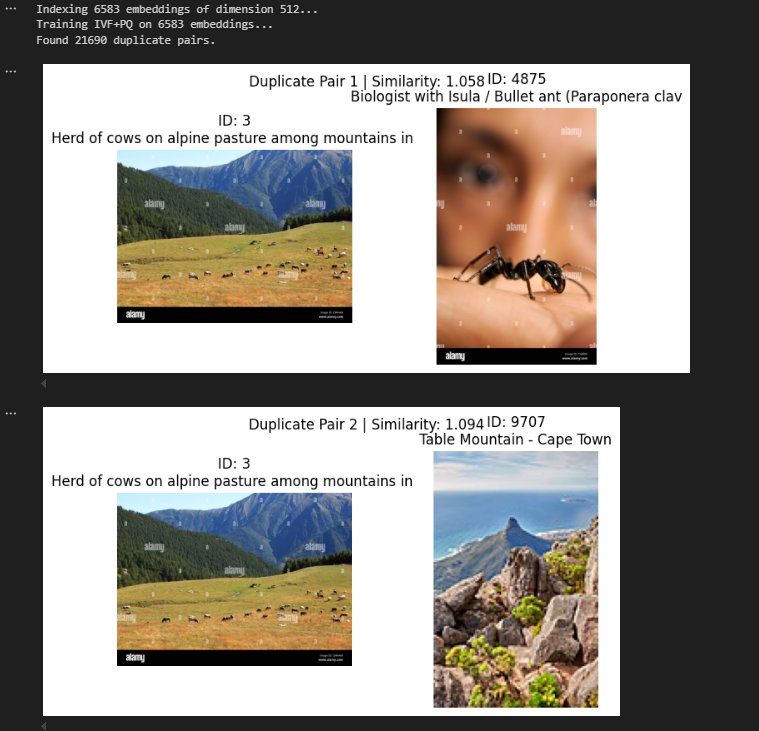

# Additional (Not 100% working) testing code

In [ ]:
import pandas as pd
import numpy as np
import faiss
from tqdm import tqdm
import pyarrow.parquet as pq

# Assume parse_embedding function is defined elsewhere
def parse_embedding(e):
    if e is None:
        return None
    try:
        if isinstance(e, str):
            e = ast.literal_eval(e)
        return np.array(e, dtype=np.float32)
    except Exception:
        return None

def is_valid_image(img):
    """Check if OpenCV image is non-empty and valid."""
    return (
        img is not None and
        isinstance(img, np.ndarray) and
        img.size > 0 and
        img.shape[0] > 0 and
        img.shape[1] > 0
    )

def find_embedding_candidates_multi_incremental(parquet_files, top_k=10, clip_threshold=0.7, batch_size=1000):
    print("Initializing FAISS GPU resources...")
    gpu_res = faiss.StandardGpuResources()
    dim = 512
    cpu_index = faiss.IndexFlatIP(dim)
    gpu_index = faiss.index_cpu_to_gpu(gpu_res, 0, cpu_index)
    
    df_list = []
    total_rows_processed = 0

    print("Processing Parquet files by row group and building FAISS index...")
    for file_path in tqdm(parquet_files, desc="Processing files"):
        try:
            parquet_file = pq.ParquetFile(file_path)
        except Exception as e:
            print(f"Error reading file {file_path}: {e}")
            continue

        for i in range(parquet_file.num_row_groups):
            # Read a single row group into a pyarrow table
            rg_table = parquet_file.read_row_group(i)
            # Convert to a pandas DataFrame
            df_rg = rg_table.to_pandas()
            
            df_rg['clip_embedding'] = df_rg['embeddings_result'].apply(parse_embedding)
            df_valid_rg = df_rg[df_rg['clip_embedding'].notnull()].reset_index(drop=True)
            
            if len(df_valid_rg) == 0:
                continue
                
            embeddings = np.stack(df_valid_rg['clip_embedding'].values).astype('float32')
            faiss.normalize_L2(embeddings)
            
            gpu_index.add(embeddings)
            df_list.append(df_valid_rg)
            total_rows_processed += len(df_valid_rg)

    print(f"FAISS GPU index built with {gpu_index.ntotal} total vectors.")
    
    # Concatenate all valid DataFrames for the search phase
    df_all_valid = pd.concat(df_list, ignore_index=True)

    # Search
    all_candidates = []
    print(f"Searching top-{top_k} neighbors with CLIP threshold {clip_threshold} in batches...")
    
    # The search is still done in batches to avoid overwhelming the GPU memory
    for start_idx in tqdm(range(0, len(df_all_valid), batch_size), desc="FAISS search batches"):
        end_idx = min(start_idx + batch_size, len(df_all_valid))
        batch_embeddings = np.stack(df_all_valid.loc[start_idx:end_idx-1, 'clip_embedding'].values).astype('float32')
        faiss.normalize_L2(batch_embeddings)
        
        D, I = gpu_index.search(batch_embeddings, top_k + 1)
        
        for row_idx, (neighbors, sims) in enumerate(zip(I, D)):
            src_index = df_all_valid.at[start_idx + row_idx, 'original_image_index']
            for neighbor_idx, sim_score in zip(neighbors[1:], sims[1:]):
                if sim_score >= clip_threshold:
                    tgt_index = df_all_valid.at[neighbor_idx, 'original_image_index']
                    # Add a check to avoid duplicates (e.g. (1,2) and (2,1)) and self-matching
                    if src_index != tgt_index:
                        all_candidates.append((src_index, tgt_index, sim_score))

    print(f"FAISS candidate search complete. {len(all_candidates)} pairs above threshold.")
    return df_all_valid, all_candidates

l = [r'C:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5B Testing\clip_embeddings_resumable_symlink\all_images_openai_clip_vit_large_patch14\0000_embeddings\part-00000.parquet',
     r'C:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5B Testing\clip_embeddings_resumable_symlink\all_images_openai_clip_vit_large_patch14\0000_embeddings\part-00001.parquet']
find_embedding_candidates_multi_incremental(l, top_k=10, clip_threshold=0.7, batch_size=1000)

In [ ]:
# import pandas as pd
# import numpy as np
# import faiss
# from tqdm import tqdm
# import pyarrow.parquet as pq
# import pyarrow.dataset as ds
# import ast

# def parse_embedding(e):
#     if e is None:
#         return None
#     try:
#         if isinstance(e, str):
#             e = ast.literal_eval(e)
#         return np.array(e, dtype=np.float32)
#     except Exception:
#         return None

# def is_valid_image(img):
#     """Check if OpenCV image is non-empty and valid."""
#     return (
#         img is not None and
#         isinstance(img, np.ndarray) and
#         img.size > 0 and
#         img.shape[0] > 0 and
#         img.shape[1] > 0
#     )

# def find_embedding_candidates_with_dataset(parquet_files, top_k=10, clip_threshold=0.7, batch_size=1000):
#     print("Initializing FAISS GPU resources...")
#     gpu_res = faiss.StandardGpuResources()
#     dim = None
#     cpu_index = None
#     gpu_index = None

#     df_list = []
    
#     print("Creating pyarrow dataset...")
#     # The dataset object represents all files as a single logical unit
#     try:
#         dataset = ds.dataset(parquet_files, format="parquet")
#     except Exception as e:
#         print(f"Error creating dataset: {e}")
#         return None, None

#     print("Reading data in batches and building FAISS index...")
#     # Use to_batches() to read the dataset incrementally
#     for batch in tqdm(dataset.to_batches(), desc="Processing batches"):
#         # Convert each batch to a pandas DataFrame
#         df_batch = batch.to_pandas()
        
#         df_batch['clip_embedding'] = df_batch['embeddings_result'].apply(parse_embedding)
#         df_valid_batch = df_batch[df_batch['clip_embedding'].notnull()].reset_index(drop=True)
#         print(f"Valid embeddings after parsing: {len(df_valid_batch)}")

#         if len(df_valid_batch) == 0:
#             continue
            
#         embeddings = np.stack(df_valid_batch['clip_embedding'].values).astype('float32')
#         faiss.normalize_L2(embeddings)
        
#         if dim is None:
#             dim = embeddings.shape[1]
#             cpu_index = faiss.IndexFlatIP(dim)
#             gpu_index = faiss.index_cpu_to_gpu(gpu_res, 0, cpu_index)

#         cpu_index.add(embeddings)

#         gpu_index.add(embeddings)
#         df_list.append(df_valid_batch)

#     print(f"FAISS GPU index built with {gpu_index.ntotal} total vectors.")
    
#     # Concatenate all valid DataFrames for the search phase
#     df_all_valid = pd.concat(df_list, ignore_index=True)

#     # Search
#     all_candidates = []
#     print(f"Searching top-{top_k} neighbors with CLIP threshold {clip_threshold} in batches...")
    
#     # The search is still done in batches to avoid overwhelming the GPU memory
#     for start_idx in tqdm(range(0, len(df_all_valid), batch_size), desc="FAISS search batches"):
#         end_idx = min(start_idx + batch_size, len(df_all_valid))
#         batch_embeddings = np.stack(df_all_valid.loc[start_idx:end_idx-1, 'clip_embedding'].values).astype('float32')
#         faiss.normalize_L2(batch_embeddings)
        
#         D, I = gpu_index.search(batch_embeddings, top_k + 1)
        
#         for row_idx, (neighbors, sims) in enumerate(zip(I, D)):
#             src_index = df_all_valid.at[start_idx + row_idx, 'original_image_index']
#             for neighbor_idx, sim_score in zip(neighbors[1:], sims[1:]):
#                 if sim_score >= clip_threshold:
#                     tgt_index = df_all_valid.at[neighbor_idx, 'original_image_index']
#                     if src_index != tgt_index:
#                         # Ensure pairs are unique and ordered (e.g., (1,2) but not (2,1))
#                         sorted_pair = tuple(sorted((src_index, tgt_index)))
#                         all_candidates.append((*sorted_pair, sim_score))

#     print(f"FAISS candidate search complete. {len(all_candidates)} pairs above threshold.")
#     return df_all_valid, all_candidates


import pandas as pd
import numpy as np
import faiss
from tqdm import tqdm
import pyarrow.dataset as ds
import ast

def parse_embedding(e):
    if e is None:
        return None
    try:
        if isinstance(e, str):
            e = ast.literal_eval(e)
        return np.array(e, dtype=np.float32)
    except Exception:
        return None

def find_embedding_candidates_with_dataset(parquet_files, top_k=10, clip_threshold=0.7, batch_size=1000):
    print("Initializing FAISS GPU resources...")
    gpu_res = faiss.StandardGpuResources()
    cpu_index = None # Start with no index
    gpu_index = None
    dim = None # Will be determined from the first valid batch
    
    df_list = []
    
    print("Creating pyarrow dataset...")
    try:
        dataset = ds.dataset(parquet_files, format="parquet")
    except Exception as e:
        print(f"Error creating dataset: {e}")
        return None, None

    print("Reading data in batches and building FAISS index...")
    for batch in tqdm(dataset.to_batches(), desc="Processing batches"):
        df_batch = batch.to_pandas()
        
        df_batch['clip_embedding'] = df_batch['embeddings_result'].apply(parse_embedding)
        df_valid_batch = df_batch[df_batch['clip_embedding'].notnull()].reset_index(drop=True)
        
        if len(df_valid_batch) == 0:
            print("No valid embeddings found in batch.")
            continue
            
        embeddings = np.stack(df_valid_batch['clip_embedding'].values).astype('float32')

        # Dynamically determine the dimension from the first valid batch
        print(dim)
        if dim is None:
            dim = embeddings.shape[1]
            print(f"Inferred embedding dimension from first batch: {dim}")
            cpu_index = faiss.IndexFlatIP(dim)
            gpu_index = faiss.index_cpu_to_gpu(gpu_res, 0, cpu_index)

        # Check for dimension mismatch on subsequent batches
        if embeddings.shape[1] != dim:
            print(f"Skipping batch due to dimension mismatch. Expected: {dim}, Found: {embeddings.shape[1]}")
            continue
        
        faiss.normalize_L2(embeddings)
        gpu_index.add(embeddings)
        df_list.append(df_valid_batch)

    if gpu_index is None:
        print("No valid embeddings found to build index.")
        return None, None
        
    print(f"FAISS GPU index built with {gpu_index.ntotal} total vectors.")
    
    df_all_valid = pd.concat(df_list, ignore_index=True)

    all_candidates = []
    print(f"Searching top-{top_k} neighbors with CLIP threshold {clip_threshold} in batches...")
    
    for start_idx in tqdm(range(0, len(df_all_valid), batch_size), desc="FAISS search batches"):
        end_idx = min(start_idx + batch_size, len(df_all_valid))
        batch_embeddings = np.stack(df_all_valid.loc[start_idx:end_idx-1, 'clip_embedding'].values).astype('float32')
        
        if batch_embeddings.shape[1] != dim:
            print(f"Skipping search batch due to dimension mismatch. Expected: {dim}, Found: {batch_embeddings.shape[1]}")
            continue

        faiss.normalize_L2(batch_embeddings)
        
        D, I = gpu_index.search(batch_embeddings, top_k + 1)
        
        for row_idx, (neighbors, sims) in enumerate(zip(I, D)):
            src_index = df_all_valid.at[start_idx + row_idx, 'original_image_index']
            for neighbor_idx, sim_score in zip(neighbors[1:], sims[1:]):
                if sim_score >= clip_threshold:
                    tgt_index = df_all_valid.at[neighbor_idx, 'original_image_index']
                    if src_index != tgt_index:
                        sorted_pair = tuple(sorted((src_index, tgt_index)))
                        all_candidates.append((*sorted_pair, sim_score))

    print(f"FAISS candidate search complete. {len(all_candidates)} pairs above threshold.")
    return df_all_valid, all_candidates

from pathlib import Path

# Assume get_all_parquet_files is defined as before
def get_all_parquet_files(volume_paths):
    all_files = []
    for volume_path in volume_paths:
        path = Path(volume_path)
        files_in_volume = list(path.glob('*.parquet'))
        all_files.extend(files_in_volume)
    return all_files

# The directory containing the parquet files
parquet_directory = r"C:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5B Testing\clip_embeddings_resumable_symlink\all_images_openai_clip_vit_large_patch14\0000_embeddings"

# Get the list of all file paths
files_to_process = get_all_parquet_files([parquet_directory])
print(f"Found {len(files_to_process)} parquet files to process.")

# Pass the list of file paths to the main function
df_valid, all_candidates = find_embedding_candidates_with_dataset(
    files_to_process,
    top_k=10, 
    clip_threshold=0.7, 
    batch_size=1000
)


# # Example call
# # You will need to provide a list of file paths here
# find_embedding_candidates_with_dataset(
#     [r'C:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5B Testing\clip_embeddings_resumable_symlink\all_images_openai_clip_vit_large_patch14\0000_embeddings'],
#     top_k=10, 
#     clip_threshold=0.7, 
#     batch_size=1000
# )

In [ ]:
import pandas as pd
import numpy as np
import faiss
from tqdm import tqdm
import pyarrow.dataset as ds
import ast
from pathlib import Path

def parse_embedding(e):
    if e is None:
        return None
    try:
        if isinstance(e, str):
            e = ast.literal_eval(e)
        return np.array(e, dtype=np.float32)
    except Exception:
        return None

def get_all_parquet_files(volume_paths):
    all_files = []
    for volume_path in volume_paths:
        path = Path(volume_path)
        files_in_volume = list(path.glob('*.parquet'))
        all_files.extend(files_in_volume)
    return all_files

def find_embedding_candidates_with_dataset_truly_incremental(
    parquet_files, 
    top_k=10, 
    clip_threshold=0.7, 
    batch_size=1000
):
    print("Initializing FAISS GPU resources...")
    gpu_res = faiss.StandardGpuResources()
    cpu_index = None
    gpu_index = None
    dim = None
    
    # New list to map FAISS index to original image index
    index_to_original_id_map = []
    
    print("Creating pyarrow dataset...")
    try:
        dataset = ds.dataset(parquet_files, format="parquet")
    except Exception as e:
        print(f"Error creating dataset: {e}")
        return None, None
    
    print("Building FAISS index incrementally...")
    # You can specify a batch size here as well, if the default is too large
    for batch in tqdm(dataset.to_batches(), desc="Processing batches"):
        df_batch = batch.to_pandas()
        
        df_batch['clip_embedding'] = df_batch['embeddings_result'].apply(parse_embedding)
        df_valid_batch = df_batch[df_batch['clip_embedding'].notnull()].reset_index(drop=True)
        
        if len(df_valid_batch) == 0:
            continue
        
        embeddings = np.stack(df_valid_batch['clip_embedding'].values).astype('float32')

        if dim is None:
            dim = embeddings.shape[1]
            print(f"Inferred embedding dimension from first batch: {dim}")
            cpu_index = faiss.IndexFlatIP(dim)
            gpu_index = faiss.index_cpu_to_gpu(gpu_res, 0, cpu_index)
        
        if embeddings.shape[1] != dim:
            print(f"Skipping batch due to dimension mismatch. Expected: {dim}, Found: {embeddings.shape[1]}")
            continue

        faiss.normalize_L2(embeddings)
        gpu_index.add(embeddings)
        
        # Append original image indices to the map
        index_to_original_id_map.extend(df_valid_batch['original_image_index'].tolist())

    if gpu_index is None:
        print("No valid embeddings found to build index.")
        return None, None
    
    print(f"FAISS GPU index built with {gpu_index.ntotal} total vectors.")
    
    all_candidates = []
    
    print(f"Searching top-{top_k} neighbors with CLIP threshold {clip_threshold} in batches...")
    
    # Now, use the FAISS index to perform the search in batches
    # We still need a way to get the search embeddings without reloading all the data.
    # The most memory-efficient way is to re-read the data in batches for the search.
    # This avoids holding a full DataFrame in memory.
    
    # Re-create a dataset object for the search phase to keep memory low
    search_dataset = ds.dataset(parquet_files, format="parquet")
    
    for batch in tqdm(search_dataset.to_batches(batch_size=batch_size), desc="FAISS search batches"):
        df_search_batch = batch.to_pandas()
        df_search_batch['clip_embedding'] = df_search_batch['embeddings_result'].apply(parse_embedding)
        df_search_valid = df_search_batch[df_search_batch['clip_embedding'].notnull()].reset_index(drop=True)

        if len(df_search_valid) == 0:
            continue
            
        search_embeddings = np.stack(df_search_valid['clip_embedding'].values).astype('float32')
        
        if search_embeddings.shape[1] != dim:
            continue
            
        faiss.normalize_L2(search_embeddings)
        
        D, I = gpu_index.search(search_embeddings, top_k + 1)
        
        for row_idx, (neighbors, sims) in enumerate(zip(I, D)):
            # Use the original_image_index from the search batch for the source
            src_index = df_search_valid.at[row_idx, 'original_image_index']
            for neighbor_faiss_idx, sim_score in zip(neighbors[1:], sims[1:]):
                if sim_score >= clip_threshold:
                    # Map the neighbor's FAISS index back to its original ID
                    tgt_index = index_to_original_id_map[neighbor_faiss_idx]
                    
                    if src_index != tgt_index:
                        sorted_pair = tuple(sorted((src_index, tgt_index)))
                        all_candidates.append((*sorted_pair, sim_score))

    print(f"FAISS candidate search complete. {len(all_candidates)} pairs above threshold.")
    
    # Return a DataFrame of ALL valid images for the next steps
    # Note: this will still be large, but it's only created after the search.
    # If this is still too big, you may need to save the candidates to a file instead.
    df_all_valid = pd.concat(
        [b.to_pandas()[b.to_pandas()['clip_embedding'].notnull()] for b in dataset.to_batches()],
        ignore_index=True
    )
    
    return df_all_valid, list(set(all_candidates))


from pathlib import Path

# Assume get_all_parquet_files is defined as before
def get_all_parquet_files(volume_paths):
    all_files = []
    for volume_path in volume_paths:
        path = Path(volume_path)
        files_in_volume = list(path.glob('*.parquet'))
        all_files.extend(files_in_volume)
    return all_files

# The directory containing the parquet files
parquet_directory = r"C:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5B Testing\clip_embeddings_resumable_symlink\all_images_openai_clip_vit_large_patch14\0000_embeddings"

# Get the list of all file paths
files_to_process = get_all_parquet_files([parquet_directory])
print(f"Found {len(files_to_process)} parquet files to process.")

# Pass the list of file paths to the main function
df_valid, all_candidates = find_embedding_candidates_with_dataset_truly_incremental(
    files_to_process[:2],
    top_k=10, 
    clip_threshold=0.7, 
    batch_size=1000
)

# Donwload iamges test logic

In [ ]:
# # import pandas as pd
# # from pathlib import Path
# # from concurrent.futures import ThreadPoolExecutor
# # from tqdm import tqdm
# # from PIL import Image
# # from io import BytesIO
# # import requests
# # import time

# # def save_fetched_images(parquet_path, fetch_image_func, batch_size=1000, number_of_workers=8, download_root="./downloads"):
# #     """
# #     Fetches images using the provided fetch_image function and saves them to disk.
# #     Resumes automatically if the download directory already exists.

# #     Args:
# #         parquet_path: Path to the Parquet file.
# #         fetch_image_func: Function that takes (index, row) and returns (index, url, caption, image).
# #         batch_size: Number of rows to process per batch.
# #         number_of_workers: Number of threads for parallel downloads.
# #         download_root: Root directory to store images.

# #     Returns:
# #         List of failures (index, url, caption) where images could not be fetched or saved.
# #     """
# #     df = pd.read_parquet(parquet_path)
# #     print(f"Total rows loaded: {len(df)}")

# #     # Create download directory based on parquet file name
# #     parquet_name = Path(parquet_path).stem
# #     download_dir = Path(download_root) / parquet_name
# #     download_dir.mkdir(parents=True, exist_ok=True)
# #     print(f"Images will be saved to: {download_dir}")

# #     # Determine which images are already downloaded
# #     existing_images = {int(p.stem) for p in download_dir.glob("*.jpg") if p.stem.isdigit()}
# #     print(f"{len(existing_images)} images already exist, will skip them.")

# #     failures = []

# #     for batch_start in tqdm(range(0, len(df), batch_size), desc="Processing Batches"):
# #         batch_end = min(batch_start + batch_size, len(df))
# #         batch_rows = [(idx, row) for idx, row in df.iloc[batch_start:batch_end].iterrows() if idx not in existing_images]

# #         if not batch_rows:
# #             continue  # skip empty batch

# #         start_time = time.time()
# #         with ThreadPoolExecutor(max_workers=number_of_workers) as executor:
# #             results = list(executor.map(fetch_image_func, batch_rows))
# #         elapsed = time.time() - start_time
# #         print(f"Batch {batch_start}-{batch_end} processed in {elapsed:.2f}s")

# #         # Save images and collect failures
# #         for index, url, caption, image in results:
# #             if image is None:
# #                 failures.append((index, url, caption))
# #                 continue
# #             try:
# #                 image_path = download_dir / f"{index}.jpg"
# #                 if not image_path.exists():
# #                     image.save(image_path)
# #             except Exception:
# #                 failures.append((index, url, caption))

# #         # Clear batch from memory
# #         del results, batch_rows

# #     print(f"Finished saving all images. Total failures: {len(failures)}")
# #     return failures

# import pandas as pd
# from pathlib import Path
# import asyncio
# import aiohttp
# from aiohttp import ClientTimeout
# from PIL import Image
# from io import BytesIO
# from tqdm.asyncio import tqdm_asyncio

# async def fetch_and_save(session, index, url, download_dir):
#     """
#     Fetch a single image and save it to disk.
#     Returns None if successful, or a tuple with (index, url, error) on failure.
#     """
#     image_path = download_dir / f"{index}.jpg"
#     if image_path.exists():
#         return None  # skip already downloaded

#     try:
#         async with session.get(url) as response:
#             response.raise_for_status()
#             content = await response.read()
#             image = Image.open(BytesIO(content)).convert("RGB")
#             image.save(image_path)
#         return None
#     except Exception as e:
#         return (index, url, str(e))

# async def download_images_async(parquet_path, download_root="./image_cache", batch_size=500, concurrent_requests=100):
#     """
#     Downloads images from a Parquet file using asyncio and aiohttp.
#     Saves images named by their original index into a subdirectory per Parquet file.
#     """
#     df = pd.read_parquet(parquet_path)
#     print(f"Total rows loaded: {len(df)}")

#     parquet_name = Path(parquet_path).stem
#     download_dir = Path(download_root) / parquet_name
#     download_dir.mkdir(parents=True, exist_ok=True)
#     print(f"Images will be saved to: {download_dir}")

#     # Skip already downloaded images
#     existing_images = {int(p.stem) for p in download_dir.glob("*.jpg") if p.stem.isdigit()}
#     print(f"{len(existing_images)} images already exist, will skip them.")

#     failures = []

#     timeout = ClientTimeout(total=15)  # seconds
#     connector = aiohttp.TCPConnector(limit=concurrent_requests)  # max concurrent connections

#     async with aiohttp.ClientSession(timeout=timeout, connector=connector) as session:
#         for batch_start in range(0, len(df), batch_size):
#             batch_end = min(batch_start + batch_size, len(df))
#             batch_rows = [(idx, row["url"]) for idx, row in df.iloc[batch_start:batch_end].iterrows() if idx not in existing_images]
#             if not batch_rows:
#                 continue

#             tasks = [fetch_and_save(session, idx, url, download_dir) for idx, url in batch_rows]

#             # Run tasks concurrently with tqdm progress bar
#             for f in tqdm_asyncio.as_completed(tasks, total=len(tasks), desc=f"Batch {batch_start}-{batch_end}"):
#                 result = await f
#                 if result is not None:
#                     failures.append(result)

#     print(f"Finished downloading all images. Total failures: {len(failures)}")
#     return failures

#### Working Find Duplicates using CLIP embeddings using IndexIVFFlat

In [ ]:
import pandas as pd
import numpy as np
import faiss
from tqdm import tqdm
import pyarrow.dataset as ds
import ast
from pathlib import Path
import random
import gc

def parse_embedding(e):
    if e is None:
        return None
    try:
        if isinstance(e, str):
            e = ast.literal_eval(e)
        return np.array(e, dtype=np.float32)
    except Exception:
        return None

def get_all_parquet_files(volume_paths):
    all_files = []
    for volume_path in tqdm(volume_paths, desc="Collecting files from volumes"):
        path = Path(volume_path)
        files_in_volume = list(path.glob('*.parquet'))
        all_files.extend(files_in_volume)
    print(f"\nFound {len(all_files)} total parquet files to process.")
    return all_files

# Works but very slow on 4Mil subset
def find_embedding_candidates_with_dataset_truly_incremental(
    parquet_files, 
    top_k=10, 
    clip_threshold=0.7, 
    batch_size=1000, 
    nlist=4096,   # IVF: number of clusters
    nprobe=16,    # IVF: number of clusters to search
    train_samples=200000  # how many vectors to sample for training
):
    print("Initializing FAISS GPU resources...")
    gpu_res = faiss.StandardGpuResources()
    cpu_index = None
    gpu_index = None
    dim = None
    
    index_to_original_id_map = []
    
    print("Creating pyarrow dataset...")
    try:
        dataset = ds.dataset(parquet_files, format="parquet")
    except Exception as e:
        print(f"Error creating dataset: {e}")
        return None
    
    total_rows = dataset.count_rows()
    print(f"Total rows in dataset: {total_rows}")

    # ----------------------------------------------------
    # Step 1: Collect a training sample for IVF
    # ----------------------------------------------------
    print(f"Sampling ~{train_samples} vectors for IVF training...")
    sample_embeddings = []
    for batch in dataset.to_batches(batch_size=batch_size):
        df = batch.to_pandas()
        df['clip_embedding'] = df['embeddings_result'].apply(parse_embedding)
        valid = df[df['clip_embedding'].notnull()]
        if len(valid) > 0:
            emb = np.stack(valid['clip_embedding'].values).astype('float32')
            sample_embeddings.append(emb)
            if sum(len(x) for x in sample_embeddings) >= train_samples:
                break
    sample_embeddings = np.vstack(sample_embeddings)[:train_samples]
    faiss.normalize_L2(sample_embeddings)
    
    dim = sample_embeddings.shape[1]
    quantizer = faiss.IndexFlatIP(dim)
    cpu_index = faiss.IndexIVFFlat(quantizer, dim, nlist, faiss.METRIC_INNER_PRODUCT)
    gpu_index = faiss.index_cpu_to_gpu(gpu_res, 0, cpu_index)

    print("Training IVF index...")
    gpu_index.train(sample_embeddings)

    # ----------------------------------------------------
    # Step 2: Build the index incrementally
    # ----------------------------------------------------
    print("Building FAISS IVF index incrementally...")
    for batch in tqdm(dataset.to_batches(batch_size=batch_size*10), desc="Adding embeddings"):
        df_batch = batch.to_pandas()
        df_batch['clip_embedding'] = df_batch['embeddings_result'].apply(parse_embedding)
        df_valid = df_batch[df_batch['clip_embedding'].notnull()].reset_index(drop=True)
        if len(df_valid) == 0:
            continue
        embeddings = np.stack(df_valid['clip_embedding'].values).astype('float32')
        if embeddings.shape[1] != dim:
            continue
        faiss.normalize_L2(embeddings)
        gpu_index.add(embeddings)
        index_to_original_id_map.extend(df_valid['original_image_index'].tolist())

        del df_batch, df_valid, embeddings
        gc.collect()

    print(f"FAISS IVF index built with {gpu_index.ntotal} total vectors.")

    # ----------------------------------------------------
    # Step 3: Search in batches
    # ----------------------------------------------------
    gpu_index.nprobe = nprobe
    all_candidates = []

    print(f"Searching top-{top_k} neighbors with CLIP threshold {clip_threshold}...")
    # search_dataset = ds.dataset(parquet_files, format="parquet")

    processed_rows = 0
    # for batch in tqdm(search_dataset.to_batches(batch_size=batch_size), desc="Searching"):
    for batch in tqdm(dataset.to_batches(batch_size=batch_size), desc="Searching"):
        df_search_batch = batch.to_pandas()
        df_search_batch['clip_embedding'] = df_search_batch['embeddings_result'].apply(parse_embedding)
        # df_search_valid = df_search_batch[df_search_batch['clip_embedding'].notnull()].reset_index(drop=True)
        df_search_batch = df_search_batch[df_search_batch['clip_embedding'].notnull()].reset_index(drop=True)

        # if len(df_search_valid) == 0:
        if len(df_search_batch) == 0:
            continue

        # search_embeddings = np.stack(df_search_valid['clip_embedding'].values).astype('float32')
        search_embeddings = np.stack(df_search_batch['clip_embedding'].values).astype('float32')
        if search_embeddings.shape[1] != dim:
            continue

        faiss.normalize_L2(search_embeddings)
        D, I = gpu_index.search(search_embeddings, top_k + 1)

        for row_idx, (neighbors, sims) in enumerate(zip(I, D)):
            # src_index = df_search_valid.at[row_idx, 'original_image_index']
            src_index = df_search_batch.at[row_idx, 'original_image_index']
            for neighbor_faiss_idx, sim_score in zip(neighbors[1:], sims[1:]):  # skip self
                if neighbor_faiss_idx < 0:
                    continue
                if sim_score >= clip_threshold:
                    tgt_index = index_to_original_id_map[neighbor_faiss_idx]
                    if src_index != tgt_index:
                        sorted_pair = tuple(sorted((src_index, tgt_index)))
                        all_candidates.append((*sorted_pair, sim_score))
        processed_rows += len(df_search_batch)

    print(f"FAISS candidate search complete. {len(all_candidates)} pairs above threshold.")
    return list(set(all_candidates))

#### Working Find Duplicates using CLIP embeddings using IndexIVFPQ instead of IndexIVFFlat

In [9]:
import pandas as pd
import numpy as np
import faiss
from tqdm import tqdm
import pyarrow.dataset as ds
import ast
from pathlib import Path
import gc

def parse_embedding(e):
    if e is None:
        return None
    try:
        if isinstance(e, str):
            e = ast.literal_eval(e)
        return np.array(e, dtype=np.float32)
    except Exception:
        return None

def get_all_parquet_files(volume_paths):
    all_files = []
    for volume_path in tqdm(volume_paths, desc="Collecting files from volumes"):
        path = Path(volume_path)
        files_in_volume = list(path.glob('*.parquet'))
        all_files.extend(files_in_volume)
    print(f"\nFound {len(all_files)} total parquet files to process.")
    return all_files


def find_embedding_candidates_with_ivfpq(
    parquet_files, 
    top_k=10, 
    clip_threshold=0.7, 
    batch_size=1000, 
    nlist=4096,     # IVF: number of clusters
    nprobe=16,      # IVF: number of clusters to search
    train_samples=200000, 
    m=32,           # number of subquantizers for PQ
    nbits=8         # bits per subquantizer (typical: 8)
):
    print("Initializing FAISS GPU resources...")
    gpu_res = faiss.StandardGpuResources()
    cpu_index = None
    gpu_index = None
    dim = None
    
    index_to_original_id_map = []
    
    print("Creating pyarrow dataset...")
    dataset = ds.dataset(parquet_files, format="parquet")
    total_rows = dataset.count_rows()
    print(f"Total rows in dataset: {total_rows}")

    # ----------------------------------------------------
    # Step 1: Collect training samples
    # ----------------------------------------------------
    print(f"Sampling ~{train_samples} vectors for IVFPQ training...")
    sample_embeddings = []
    for batch in dataset.to_batches(batch_size=batch_size):
        df = batch.to_pandas()
        df['clip_embedding'] = df['embeddings_result'].apply(parse_embedding)
        valid = df[df['clip_embedding'].notnull()]
        if len(valid) > 0:
            emb = np.stack(valid['clip_embedding'].values).astype('float32')
            sample_embeddings.append(emb)
            if sum(len(x) for x in sample_embeddings) >= train_samples:
                break
    sample_embeddings = np.vstack(sample_embeddings)[:train_samples]
    faiss.normalize_L2(sample_embeddings)
    
    dim = sample_embeddings.shape[1]

    # Build IVFPQ index
    quantizer = faiss.IndexFlatIP(dim)
    cpu_index = faiss.IndexIVFPQ(
        quantizer, dim, nlist, m, nbits, faiss.METRIC_INNER_PRODUCT
    )
    gpu_index = faiss.index_cpu_to_gpu(gpu_res, 0, cpu_index)

    print("Training IVFPQ index...")
    gpu_index.train(sample_embeddings)

    # ----------------------------------------------------
    # Step 2: Add data to the index
    # ----------------------------------------------------
    print("Building FAISS IVFPQ index incrementally...")
    for batch in tqdm(dataset.to_batches(batch_size=batch_size*10), desc="Adding embeddings"):
        df_batch = batch.to_pandas()
        df_batch['clip_embedding'] = df_batch['embeddings_result'].apply(parse_embedding)
        df_valid = df_batch[df_batch['clip_embedding'].notnull()].reset_index(drop=True)
        if len(df_valid) == 0:
            continue
        embeddings = np.stack(df_valid['clip_embedding'].values).astype('float32')
        if embeddings.shape[1] != dim:
            continue
        faiss.normalize_L2(embeddings)
        gpu_index.add(embeddings)
        index_to_original_id_map.extend(df_valid['original_image_index'].tolist())

        del df_batch, df_valid, embeddings
        gc.collect()

    print(f"FAISS IVFPQ index built with {gpu_index.ntotal} total vectors.")

    # ----------------------------------------------------
    # Step 3: Search
    # ----------------------------------------------------
    gpu_index.nprobe = nprobe
    all_candidates = []

    print(f"Searching top-{top_k} neighbors with CLIP threshold {clip_threshold}...")
    for batch in tqdm(dataset.to_batches(batch_size=batch_size), desc="Searching"):
        df_search_batch = batch.to_pandas()
        df_search_batch['clip_embedding'] = df_search_batch['embeddings_result'].apply(parse_embedding)
        df_search_batch = df_search_batch[df_search_batch['clip_embedding'].notnull()].reset_index(drop=True)

        if len(df_search_batch) == 0:
            continue

        search_embeddings = np.stack(df_search_batch['clip_embedding'].values).astype('float32')
        if search_embeddings.shape[1] != dim:
            continue

        faiss.normalize_L2(search_embeddings)
        D, I = gpu_index.search(search_embeddings, top_k + 1)

        for row_idx, (neighbors, sims) in enumerate(zip(I, D)):
            src_index = df_search_batch.at[row_idx, 'original_image_index']
            for neighbor_faiss_idx, sim_score in zip(neighbors[1:], sims[1:]):
                if neighbor_faiss_idx < 0:
                    continue
                if sim_score >= clip_threshold:
                    tgt_index = index_to_original_id_map[neighbor_faiss_idx]
                    if src_index != tgt_index:
                        sorted_pair = tuple(sorted((src_index, tgt_index)))
                        all_candidates.append((*sorted_pair, sim_score))

    print(f"FAISS candidate search complete. {len(all_candidates)} pairs above threshold.")
    return list(set(all_candidates))


In [10]:
files_to_process = [r"C:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5B Testing\clip_embeddings_resumable_symlink\all_images_openai_clip_vit_large_patch14\0000_embeddings\part-00000.parquet",
                    r"C:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5B Testing\clip_embeddings_resumable_symlink\all_images_openai_clip_vit_large_patch14\0000_embeddings\part-00001.parquet"]

all_candidates = find_embedding_candidates_with_ivfpq(
    files_to_process, 
    top_k=10, 
    clip_threshold=0.7, 
    batch_size=1000, 
    nlist=4096,     # IVF: number of clusters
    nprobe=16,      # IVF: number of clusters to search
    train_samples=200000, 
    m=32,           # number of subquantizers for PQ
    nbits=8         # bits per subquantizer (typical: 8)
)

Initializing FAISS GPU resources...
Creating pyarrow dataset...
Total rows in dataset: 4000000
Sampling ~200000 vectors for IVFPQ training...
Training IVFPQ index...
Building FAISS IVFPQ index incrementally...


Adding embeddings: 400it [03:44,  1.79it/s]


FAISS IVFPQ index built with 2649946 total vectors.
Searching top-10 neighbors with CLIP threshold 0.7...


Searching: 4000it [04:04, 16.35it/s]


FAISS candidate search complete. 18039268 pairs above threshold.


In [ ]:
from pympler import asizeof
def get_size_info(object):
    '''Returns the size of an object in bytes and gigabytes, and prints it formatted.'''
    size_bytes = asizeof.asizeof(object)
    size_gb = size_bytes / (1024 ** 3)
    print(f"{size_gb:.2f} GB")
    return size_bytes, size_gb

get_size_info(all_candidates)

1.83 GB


#### Working ORB Search

In [29]:
import os
import cv2
import pickle
import numpy as np
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
from itertools import groupby
from tqdm import tqdm

# -------------------- Helper --------------------
def is_valid_image(img):
    """Check if OpenCV image is non-empty and valid."""
    return (
        img is not None and
        isinstance(img, np.ndarray) and
        img.size > 0 and
        img.shape[0] > 0 and
        img.shape[1] > 0
    )

# -------------------- Streaming DSU --------------------
class StreamingDSU:
    """Memory-efficient DSU using integer mapping for streaming updates."""
    def __init__(self, elements):
        self.elem2idx = {elem: i for i, elem in enumerate(sorted(elements))}
        self.idx2elem = {i: elem for elem, i in self.elem2idx.items()}
        self.parent = np.arange(len(elements), dtype=np.int32)

    def find(self, elem):
        i = self.elem2idx[elem]
        while self.parent[i] != i:
            self.parent[i] = self.parent[self.parent[i]]  # path compression
            i = self.parent[i]
        return i

    def union(self, elem1, elem2):
        i1, i2 = self.find(elem1), self.find(elem2)
        if i1 != i2:
            self.parent[i2] = i1
            return True
        return False

    def get_groups(self):
        groups = {}
        for elem, idx in self.elem2idx.items():
            root_idx = self.find(elem)
            groups.setdefault(self.idx2elem[root_idx], []).append(elem)
        return [sorted(g) for g in groups.values() if len(g) > 1]

# -------------------- ORB Verification --------------------
def verify_with_orb_streaming(
    candidates,
    image_dir,
    orb_threshold=0.35,
    nfeatures=500,
    max_workers=8,
    checkpoint_every=1000,
    checkpoint_dir="./checkpoints"
):
    image_dir = Path(image_dir)
    image_dir.mkdir(parents=True, exist_ok=True)
    checkpoint_dir = Path(checkpoint_dir)
    checkpoint_dir.mkdir(parents=True, exist_ok=True)

    # Sort candidates by src_idx for cache efficiency
    candidates = sorted(candidates, key=lambda x: x[0])

    # Initialize DSU, cache, invalid_images, and last processed index
    all_indices = {idx for pair in candidates for idx in pair[:2]}
    dsu = StreamingDSU(all_indices)
    orb_cache = {}
    invalid_images = set()
    last_processed_idx = -1
    processed_count = 0

    # Create single ORB extractor (reused for all images)
    orb = cv2.ORB_create(nfeatures=nfeatures)

    # Initialize FLANN for Hamming distance
    index_params = dict(algorithm=6,  # FLANN_INDEX_LSH
                        table_number=6,  # 12 is a common default
                        key_size=12,     # 20 is common
                        multi_probe_level=1)  # 2 is common
    search_params = dict(checks=50)
    flann = cv2.FlannBasedMatcher(index_params, search_params)

    # -------------------- Load latest checkpoint if exists --------------------
    ckpt_files = list(checkpoint_dir.glob("dsu_checkpoint_*_*.pkl"))
    if ckpt_files:
        latest_ckpt = max(ckpt_files, key=lambda f: f.stat().st_mtime)
        processed_count = int(latest_ckpt.stem.split("_")[2])
        with open(latest_ckpt, "rb") as f:
            data = pickle.load(f)
        dsu = data['dsu']
        invalid_images = data.get('invalid_images', set())
        last_processed_idx = data.get('last_processed_idx', -1)
        candidates = [c for c in candidates if c[0] >= last_processed_idx]
        print(f"Resuming from checkpoint: {latest_ckpt}, last processed src_idx: {last_processed_idx}")

    # -------------------- Parallel ORB Extraction --------------------
    def extract_orb(idx):
        if idx in orb_cache:
            return idx, orb_cache[idx]
        img_path = image_dir / f"{idx}.jpg"
        if not img_path.exists():
            invalid_images.add(idx)
            orb_cache[idx] = (None, None)
            return idx, (None, None)
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        if not is_valid_image(img):
            invalid_images.add(idx)
            orb_cache[idx] = (None, None)
            return idx, (None, None)
        try:
            kp, des = orb.detectAndCompute(img, None)
            if kp is None or des is None or len(kp) == 0:
                invalid_images.add(idx)
                orb_cache[idx] = (None, None)
                return idx, (None, None)
        except Exception:
            invalid_images.add(idx)
            orb_cache[idx] = (None, None)
            return idx, (None, None)
        orb_cache[idx] = (kp, des)
        return idx, (kp, des)

    # -------------------- Pair Processing --------------------
    def process_pair(pair):
        src_idx, tgt_idx, _ = pair
        _, (kp1, des1) = extract_orb(src_idx)
        _, (kp2, des2) = extract_orb(tgt_idx)
        if des1 is None or des2 is None:
            return None
        try:
            matches = flann.knnMatch(des1, des2, k=2)
            good = [m for m, n in matches if len(matches) >= 2 and m.distance < 0.75 * n.distance]
            sim = len(good) / len(matches) if matches else 0.0
            if sim >= orb_threshold:
                return src_idx, tgt_idx
        except Exception:
            return None
        return None

    # -------------------- Group candidates by src_idx --------------------
    groups = groupby(candidates, key=lambda x: x[0])
    num_unique_src_ids = len(set(x[0] for x in candidates))

    for i, (src_idx, group_iter) in enumerate(tqdm(groups, total=num_unique_src_ids, desc="Streaming ORB DSU")):
        if src_idx <= last_processed_idx:
            continue

        pairs = list(group_iter)

        # Pre-extract ORB features for unique indices in this group (parallel)
        unique_idxs = {src_idx} | {tgt for _, tgt, _ in pairs}
        with ThreadPoolExecutor(max_workers=max_workers) as executor:
            futures = {executor.submit(extract_orb, idx): idx for idx in unique_idxs}
            for future in as_completed(futures):
                _ = future.result()  # fills orb_cache

        # Process verification in parallel
        with ThreadPoolExecutor(max_workers=max_workers) as executor:
            results = list(executor.map(process_pair, pairs))
        for r in results:
            if r is not None:
                dsu.union(*r)

        last_processed_idx = src_idx
        processed_count += 1

        # -------------------- Checkpoint --------------------
        if processed_count % checkpoint_every == 0:
            ckpt_file = checkpoint_dir / f"dsu_checkpoint_{processed_count}_{last_processed_idx}.pkl"
            with open(ckpt_file, "wb") as f:
                pickle.dump({
                    'dsu': dsu,
                    'invalid_images': invalid_images,
                    'last_processed_idx': last_processed_idx
                }, f)
            all_ckpts = sorted(checkpoint_dir.glob("dsu_checkpoint_*_*.pkl"),
                               key=lambda f: int(f.stem.split('_')[2]))
            for old_ckpt in all_ckpts[:-2]:
                old_ckpt.unlink(missing_ok=True)
            print(f"Checkpoint saved: {ckpt_file}, processed src_idx: {last_processed_idx}")

    # -------------------- Final groups --------------------
    final_groups = dsu.get_groups()
    print(f"Total duplicate groups found: {len(final_groups)}")
    return final_groups, invalid_images


#### Working ORB Search w CPU + GPU options (GPU requires buildings opencv-python with CUDA)

In [11]:
import os
import cv2
import pickle
import numpy as np
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
from itertools import groupby
from tqdm import tqdm

# -------------------- Helper --------------------
def is_valid_image(img):
    """Check if OpenCV image is non-empty and valid."""
    return (
        img is not None and
        isinstance(img, np.ndarray) and
        img.size > 0 and
        img.shape[0] > 0 and
        img.shape[1] > 0
    )

# -------------------- Streaming DSU --------------------
class StreamingDSU:
    """Memory-efficient DSU using integer mapping for streaming updates."""
    def __init__(self, elements):
        self.elem2idx = {elem: i for i, elem in enumerate(sorted(elements))}
        self.idx2elem = {i: elem for elem, i in self.elem2idx.items()}
        self.parent = np.arange(len(elements), dtype=np.int32)

    def find(self, elem):
        i = self.elem2idx[elem]
        while self.parent[i] != i:
            self.parent[i] = self.parent[self.parent[i]]  # path compression
            i = self.parent[i]
        return i

    def union(self, elem1, elem2):
        i1, i2 = self.find(elem1), self.find(elem2)
        if i1 != i2:
            self.parent[i2] = i1
            return True
        return False

    def get_groups(self):
        groups = {}
        for elem, idx in self.elem2idx.items():
            root_idx = self.find(elem)
            groups.setdefault(self.idx2elem[root_idx], []).append(elem)
        return [sorted(g) for g in groups.values() if len(g) > 1]

# -------------------- ORB Verification --------------------
def verify_with_orb_streaming(
    candidates,
    image_dir,
    orb_threshold=0.35,
    nfeatures=500,
    max_workers=8,
    checkpoint_every=1000,
    checkpoint_dir="./checkpoints"
):
    image_dir = Path(image_dir)
    image_dir.mkdir(parents=True, exist_ok=True)
    checkpoint_dir = Path(checkpoint_dir)
    checkpoint_dir.mkdir(parents=True, exist_ok=True)

    # Sort candidates by src_idx for cache efficiency
    candidates = sorted(candidates, key=lambda x: x[0])

    # Initialize DSU, cache, invalid_images, and last processed index
    all_indices = {idx for pair in candidates for idx in pair[:2]}
    dsu = StreamingDSU(all_indices)
    orb_cache = {}
    invalid_images = set()
    last_processed_idx = -1
    processed_count = 0

    # -------------------- CPU/GPU ORB & Matcher --------------------
    use_cuda = cv2.cuda.getCudaEnabledDeviceCount() > 0
    if use_cuda:
        print("⚡ Using CUDA ORB + BFMatcher")
        orb = cv2.cuda_ORB.create(nfeatures=nfeatures)
        matcher = cv2.cuda.DescriptorMatcher_createBFMatcher(cv2.NORM_HAMMING)

        def extract_orb(idx):
            if idx in orb_cache:
                return idx, orb_cache[idx]
            img_path = image_dir / f"{idx}.jpg"
            if not img_path.exists():
                invalid_images.add(idx)
                orb_cache[idx] = (None, None)
                return idx, (None, None)
            img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
            if not is_valid_image(img):
                invalid_images.add(idx)
                orb_cache[idx] = (None, None)
                return idx, (None, None)
            try:
                gpu_img = cv2.cuda_GpuMat()
                gpu_img.upload(img)
                kp_gpu, des_gpu = orb.detectAndComputeAsync(gpu_img, None)
                kp = orb.convert(kp_gpu)
                des = des_gpu.download() if des_gpu is not None else None
                if kp is None or des is None or len(kp) == 0:
                    invalid_images.add(idx)
                    orb_cache[idx] = (None, None)
                    return idx, (None, None)
            except Exception:
                invalid_images.add(idx)
                orb_cache[idx] = (None, None)
                return idx, (None, None)
            orb_cache[idx] = (kp, des)
            return idx, (kp, des)

        def process_pair(pair):
            src_idx, tgt_idx, _ = pair
            _, (kp1, des1) = extract_orb(src_idx)
            _, (kp2, des2) = extract_orb(tgt_idx)
            if des1 is None or des2 is None:
                return None
            try:
                d1 = cv2.cuda_GpuMat(); d2 = cv2.cuda_GpuMat()
                d1.upload(des1); d2.upload(des2)
                matches = matcher.knnMatch(d1, d2, k=2)
                good = [m for m, n in matches if m.distance < 0.75 * n.distance]
                sim = len(good) / len(matches) if matches else 0.0
                if sim >= orb_threshold:
                    return src_idx, tgt_idx
            except Exception:
                return None
            return None

    else:
        print("💻 Using CPU ORB + FLANN")
        orb = cv2.ORB_create(nfeatures=nfeatures)
        index_params = dict(algorithm=6, table_number=6, key_size=12, multi_probe_level=1)
        search_params = dict(checks=50)
        flann = cv2.FlannBasedMatcher(index_params, search_params)

        def extract_orb(idx):
            if idx in orb_cache:
                return idx, orb_cache[idx]
            img_path = image_dir / f"{idx}.jpg"
            if not img_path.exists():
                invalid_images.add(idx)
                orb_cache[idx] = (None, None)
                return idx, (None, None)
            img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
            if not is_valid_image(img):
                invalid_images.add(idx)
                orb_cache[idx] = (None, None)
                return idx, (None, None)
            try:
                kp, des = orb.detectAndCompute(img, None)
                if kp is None or des is None or len(kp) == 0:
                    invalid_images.add(idx)
                    orb_cache[idx] = (None, None)
                    return idx, (None, None)
            except Exception:
                invalid_images.add(idx)
                orb_cache[idx] = (None, None)
                return idx, (None, None)
            orb_cache[idx] = (kp, des)
            return idx, (kp, des)

        def process_pair(pair):
            src_idx, tgt_idx, _ = pair
            _, (kp1, des1) = extract_orb(src_idx)
            _, (kp2, des2) = extract_orb(tgt_idx)
            if des1 is None or des2 is None:
                return None
            try:
                matches = flann.knnMatch(des1, des2, k=2)
                good = [m for m, n in matches if m.distance < 0.75 * n.distance]
                sim = len(good) / len(matches) if matches else 0.0
                if sim >= orb_threshold:
                    return src_idx, tgt_idx
            except Exception:
                return None
            return None

    # -------------------- Load latest checkpoint if exists --------------------
    ckpt_files = list(checkpoint_dir.glob("dsu_checkpoint_*_*.pkl"))
    if ckpt_files:
        latest_ckpt = max(ckpt_files, key=lambda f: f.stat().st_mtime)
        processed_count = int(latest_ckpt.stem.split("_")[2])
        with open(latest_ckpt, "rb") as f:
            data = pickle.load(f)
        dsu = data['dsu']
        invalid_images = data.get('invalid_images', set())
        last_processed_idx = data.get('last_processed_idx', -1)
        candidates = [c for c in candidates if c[0] >= last_processed_idx]
        print(f"Resuming from checkpoint: {latest_ckpt}, last processed src_idx: {last_processed_idx}")

    # -------------------- Group candidates by src_idx --------------------
    groups = groupby(candidates, key=lambda x: x[0])
    num_unique_src_ids = len(set(x[0] for x in candidates))

    for i, (src_idx, group_iter) in enumerate(tqdm(groups, total=num_unique_src_ids, desc="Streaming ORB DSU")):
        if src_idx <= last_processed_idx:
            continue

        pairs = list(group_iter)

        # Pre-extract ORB features for unique indices in this group (parallel)
        unique_idxs = {src_idx} | {tgt for _, tgt, _ in pairs}
        with ThreadPoolExecutor(max_workers=max_workers) as executor:
            futures = {executor.submit(extract_orb, idx): idx for idx in unique_idxs}
            for future in as_completed(futures):
                _ = future.result()  # fills orb_cache

        # Process verification in parallel
        with ThreadPoolExecutor(max_workers=max_workers) as executor:
            results = list(executor.map(process_pair, pairs))
        for r in results:
            if r is not None:
                dsu.union(*r)

        last_processed_idx = src_idx
        processed_count += 1

        # -------------------- Checkpoint --------------------
        if processed_count % checkpoint_every == 0:
            ckpt_file = checkpoint_dir / f"dsu_checkpoint_{processed_count}_{last_processed_idx}.pkl"
            with open(ckpt_file, "wb") as f:
                pickle.dump({
                    'dsu': dsu,
                    'invalid_images': invalid_images,
                    'last_processed_idx': last_processed_idx
                }, f)
            all_ckpts = sorted(checkpoint_dir.glob("dsu_checkpoint_*_*.pkl"),
                               key=lambda f: int(f.stem.split('_')[2]))
            for old_ckpt in all_ckpts[:-2]:
                old_ckpt.unlink(missing_ok=True)
            print(f"Checkpoint saved: {ckpt_file}, processed src_idx: {last_processed_idx}")

    # -------------------- Final groups --------------------
    final_groups = dsu.get_groups()
    print(f"Total duplicate groups found: {len(final_groups)}")
    return final_groups, invalid_images


In [12]:
image_dir = r"clip_embeddings_resumable_symlink/downloaded_images/0000" #r"./test_image_cache/part-00000-checkpoint-1426200"

verify_with_orb_streaming(
    candidates=all_candidates,
    image_dir=image_dir,
    orb_threshold=0.35,
    nfeatures=500,
    max_workers=32,
    checkpoint_every=1000,
    checkpoint_dir="./0000_dsu_checkpoints_1"
)

💻 Using CPU ORB + FLANN


Streaming ORB DSU:   0%|          | 1017/1731078 [00:24<55:41:54,  8.63it/s]

Checkpoint saved: 0000_dsu_checkpoints_1\dsu_checkpoint_1000_1956.pkl, processed src_idx: 1956


Streaming ORB DSU:   0%|          | 2011/1731078 [00:45<60:12:53,  7.98it/s]

Checkpoint saved: 0000_dsu_checkpoints_1\dsu_checkpoint_2000_3912.pkl, processed src_idx: 3912


...

Checkpoint saved: 0000_dsu_checkpoints_1\dsu_checkpoint_10000_19574.pkl, processed src_idx: 19574


Streaming ORB DSU:   1%|          | 11006/1731078 [04:02<73:06:44,  6.54it/s]

Checkpoint saved: 0000_dsu_checkpoints_1\dsu_checkpoint_11000_21511.pkl, processed src_idx: 21511


Streaming ORB DSU:   1%|          | 11495/1731078 [04:48<11:58:24, 39.89it/s] 


KeyboardInterrupt: 

In [13]:
import matplotlib.pyplot as plt
from pathlib import Path
import cv2
import numpy as np

def show_duplicate_groups(grouped_duplicates, image_dir, max_groups=10):
    """
    Displays groups of duplicate images.

    grouped_duplicates: list of lists, where each inner list contains indices of images in a group.
    image_dir: Path to folder with images named [original_image_index].jpg
    max_groups: maximum number of groups to display
    """
    image_dir = Path(image_dir)

    for i, group in enumerate(grouped_duplicates[:max_groups]):

        if len(group) < 2:
            continue

        print(f"Displaying Group {i+1} with {len(group)} images...")
        group = group[:2]  # limit to first 20 images per group for display
        
        # Dynamically determine the grid size for the subplots
        num_images = len(group)
        cols = int(np.ceil(np.sqrt(num_images)))
        rows = int(np.ceil(num_images / cols))
        
        # Create a new figure for each group
        plt.figure(figsize=(cols * 4, rows * 4))
        plt.suptitle(f"Duplicate Group {i+1}", fontsize=16)

        for j, img_idx in enumerate(group):
            img_path = image_dir / f"{img_idx}.jpg"
            img = cv2.imread(str(img_path))

            if img is None:
                print(f"Skipping image {img_idx} – file not found.")
                continue

            # Convert BGR to RGB for matplotlib
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # Add a subplot for each image in the group
            ax = plt.subplot(rows, cols, j + 1)
            ax.imshow(img)
            ax.set_title(f"Image {img_idx}")
            ax.axis('off')

        # Adjust layout to prevent titles from overlapping and display the figure
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

Displaying Group 1 with 158 images...


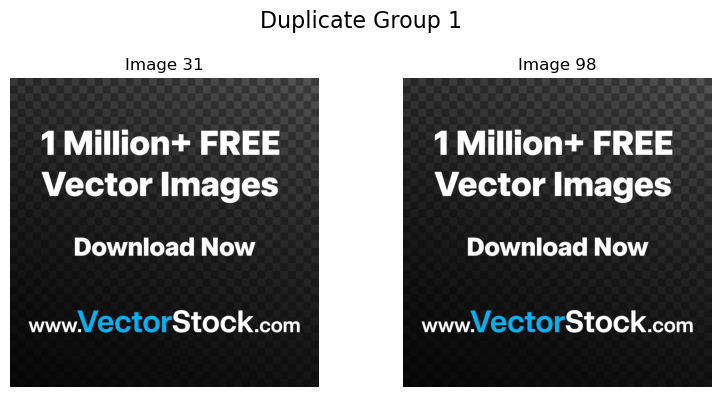

Displaying Group 2 with 7 images...


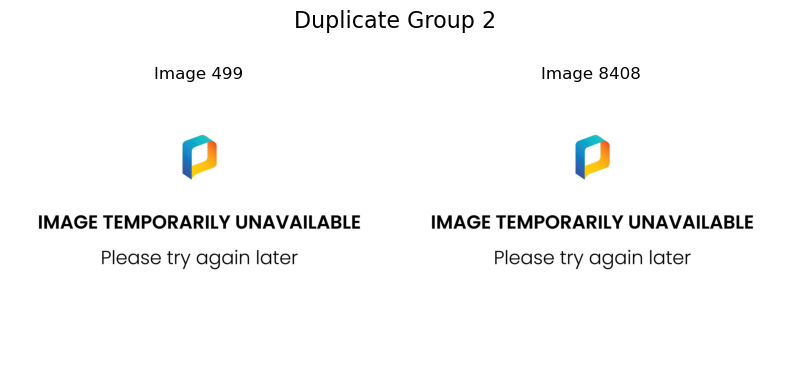

Displaying Group 3 with 2 images...


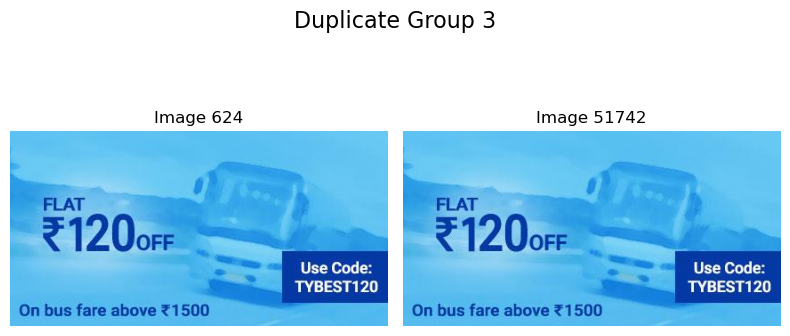

Displaying Group 4 with 5 images...


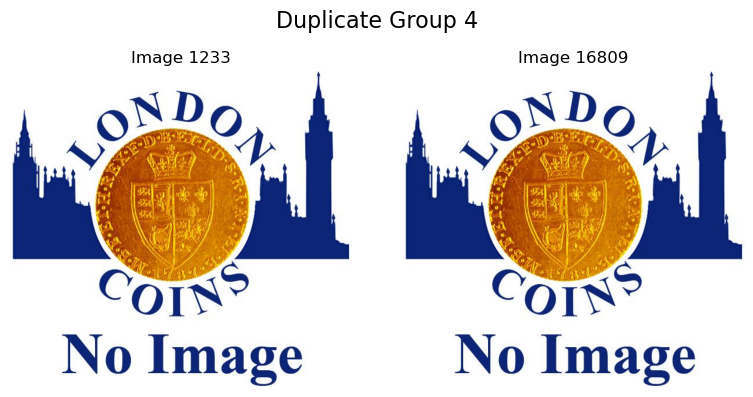

Displaying Group 5 with 5 images...


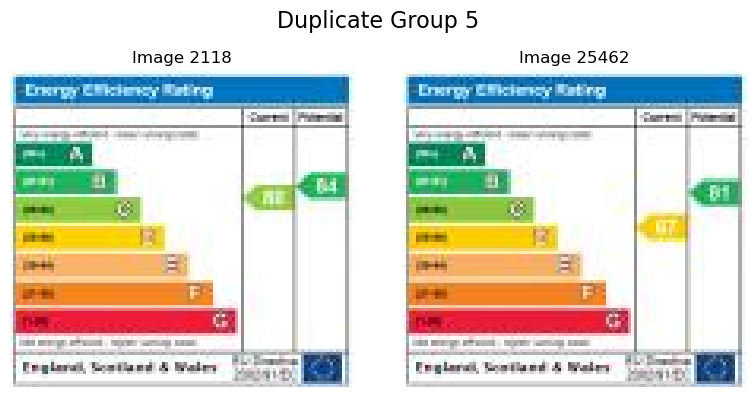

Displaying Group 6 with 2 images...


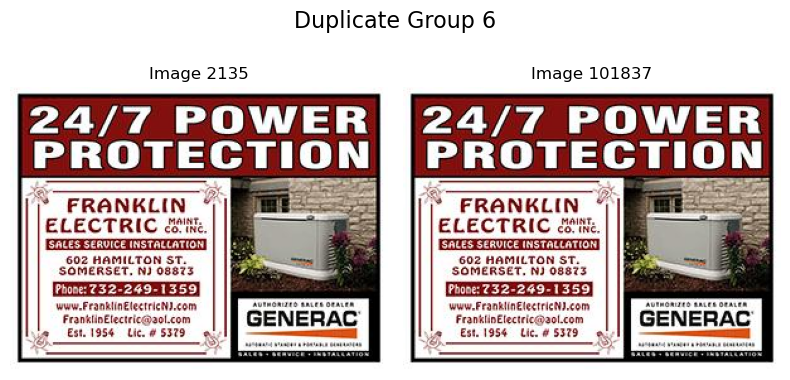

Displaying Group 7 with 2 images...


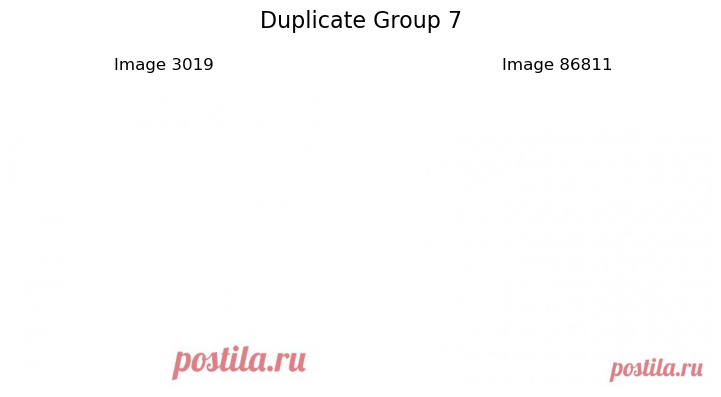

Displaying Group 8 with 8 images...


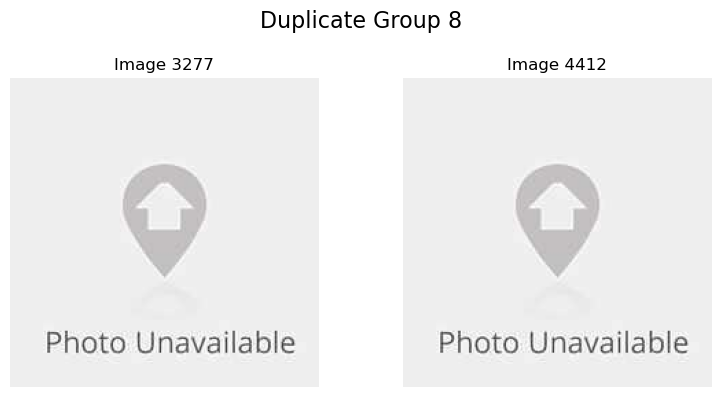

Displaying Group 9 with 28 images...


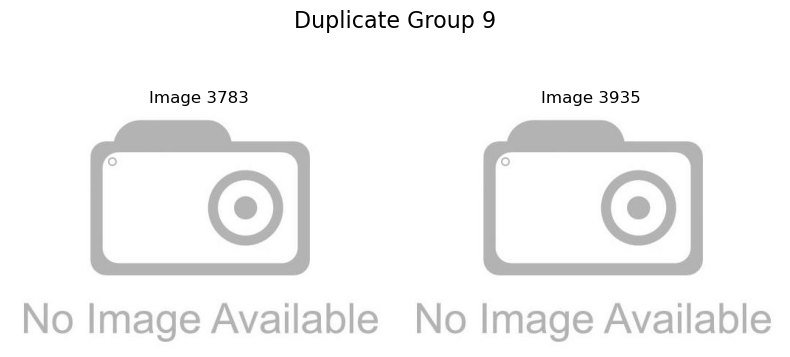

Displaying Group 10 with 16 images...


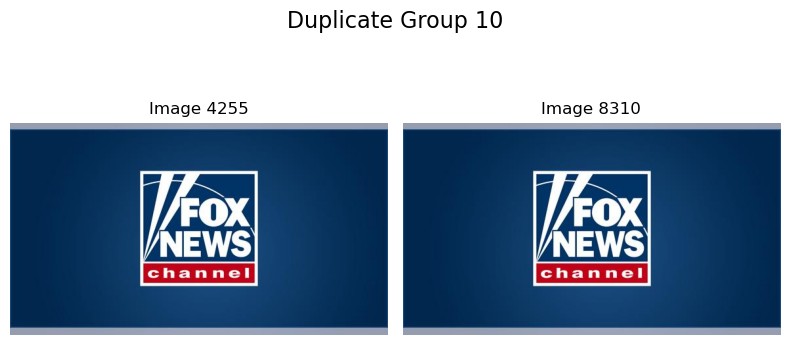

Displaying Group 11 with 5 images...


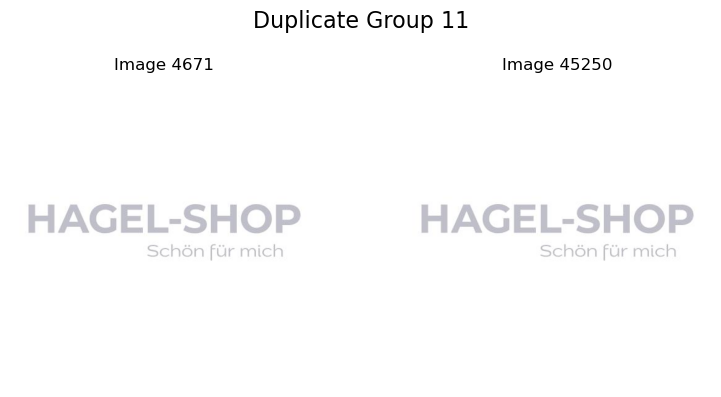

Displaying Group 12 with 2 images...


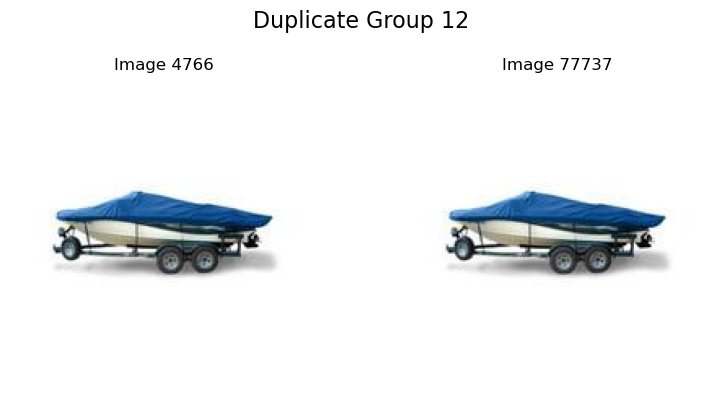

Displaying Group 13 with 23 images...


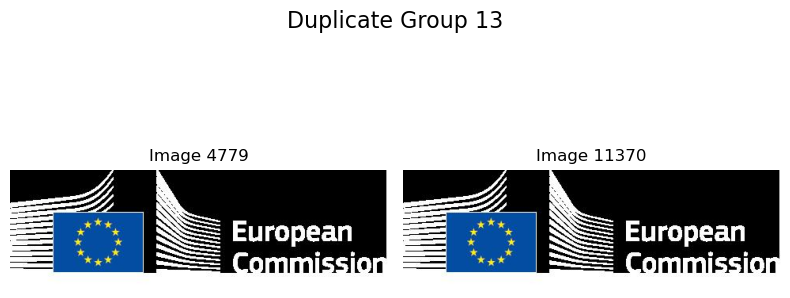

Displaying Group 14 with 12 images...


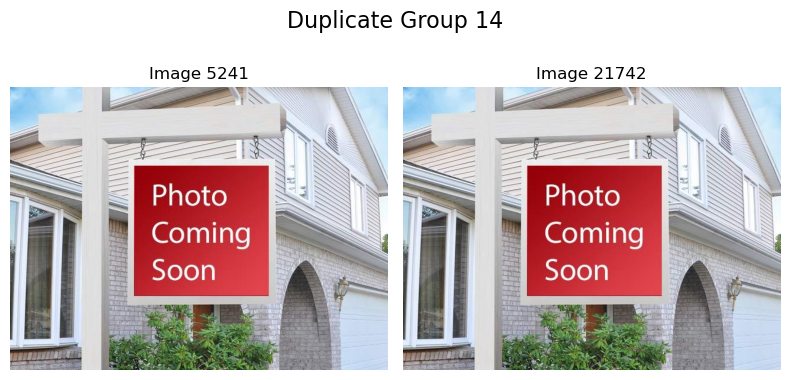

Displaying Group 15 with 3 images...


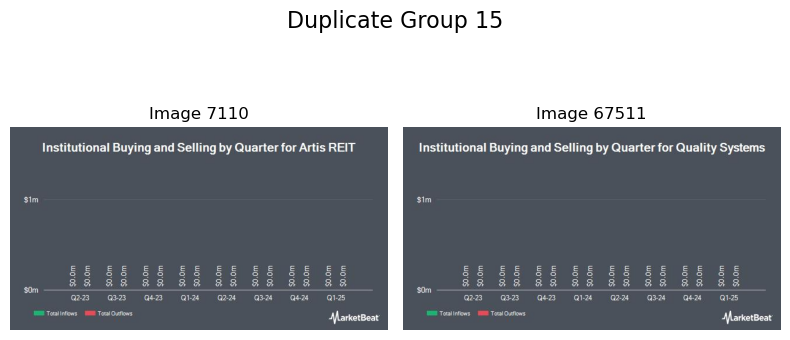

Displaying Group 16 with 4 images...


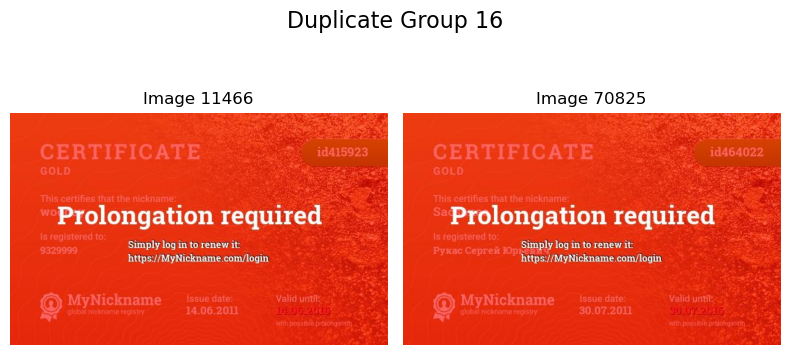

Displaying Group 17 with 2 images...


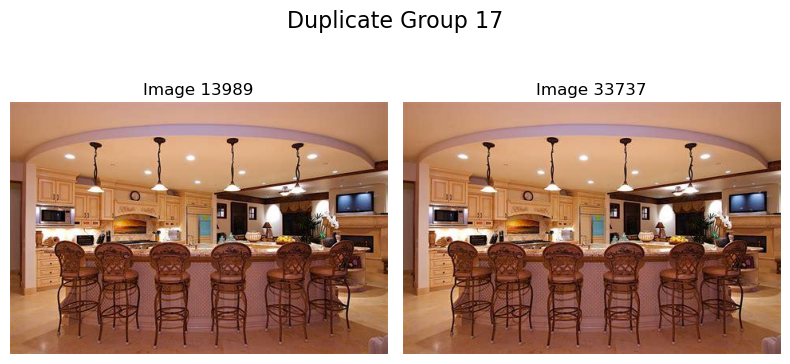

Displaying Group 18 with 2 images...


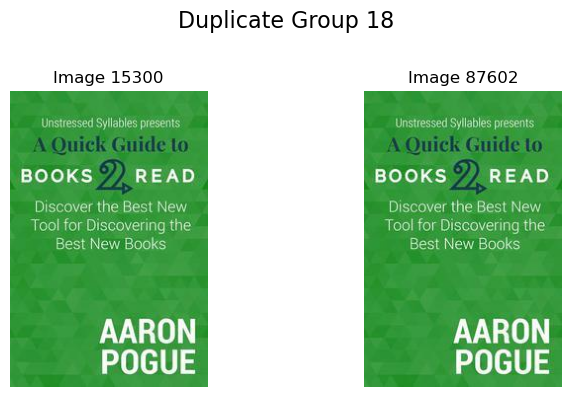

Displaying Group 19 with 3 images...


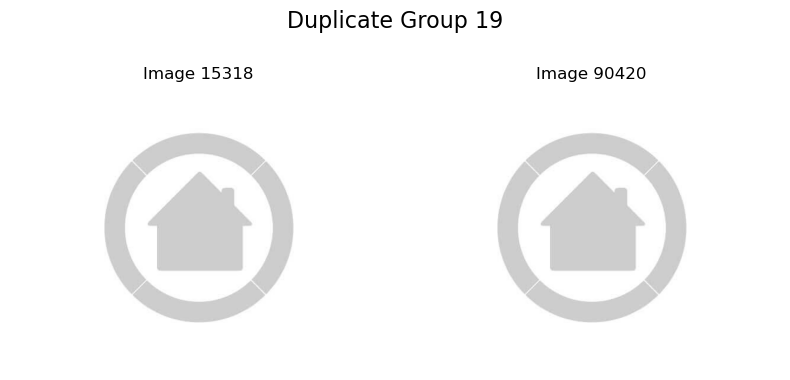

Displaying Group 20 with 2 images...


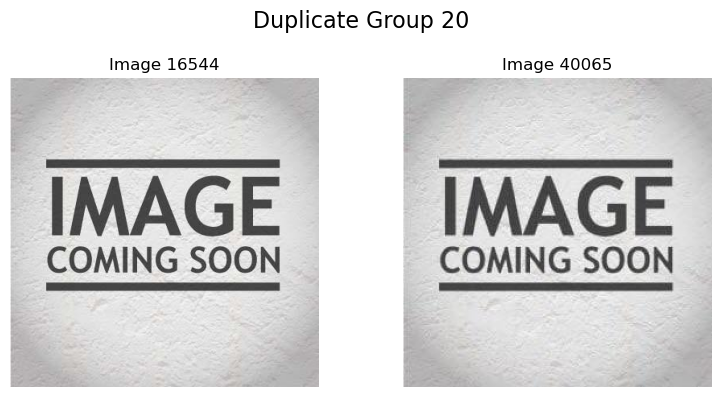

Displaying Group 21 with 3 images...


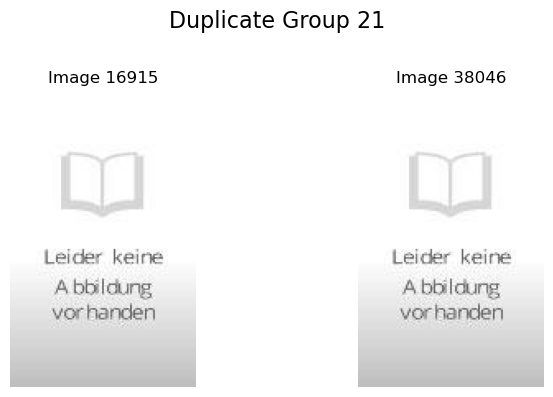

Displaying Group 22 with 3 images...


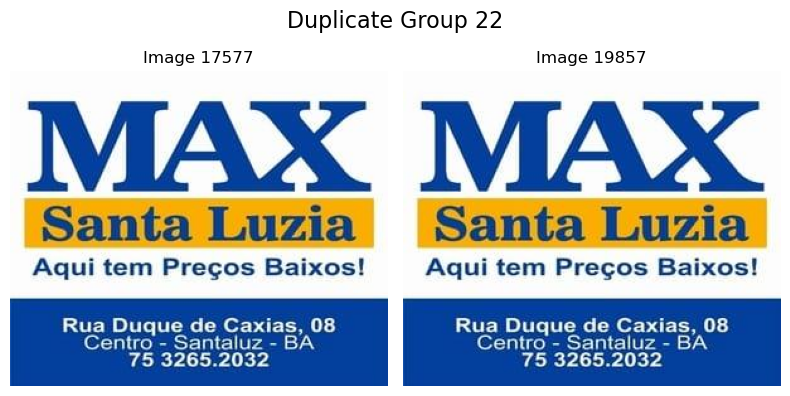

Displaying Group 23 with 2 images...


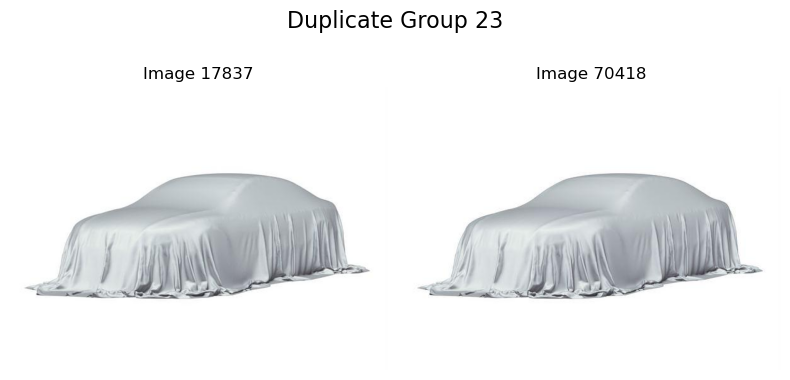

Displaying Group 24 with 2 images...


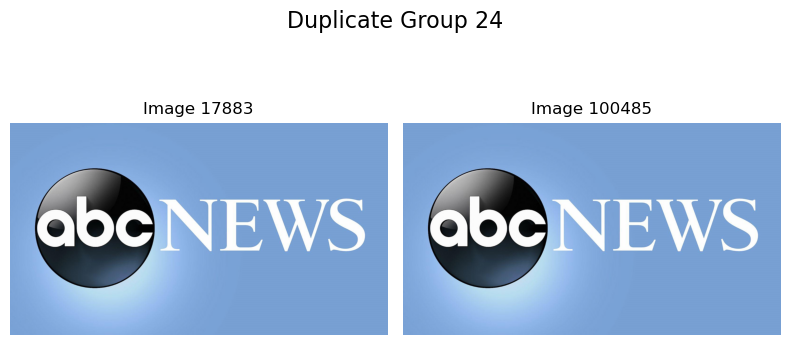

Displaying Group 25 with 3 images...


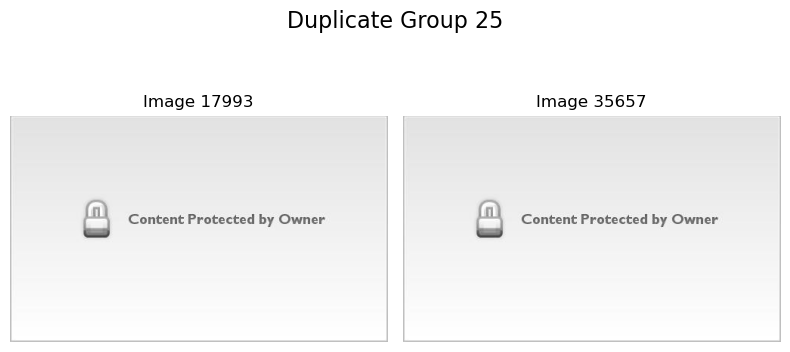

Displaying Group 26 with 2 images...


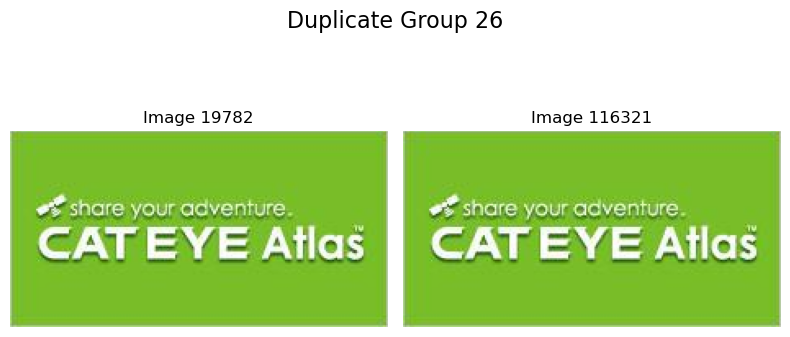

Displaying Group 27 with 2 images...


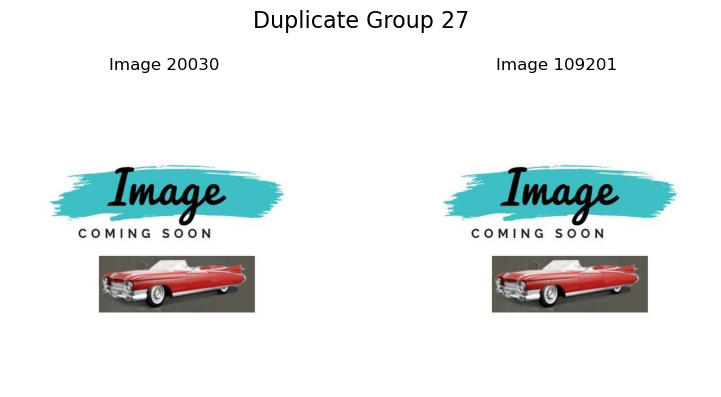

Displaying Group 28 with 2 images...


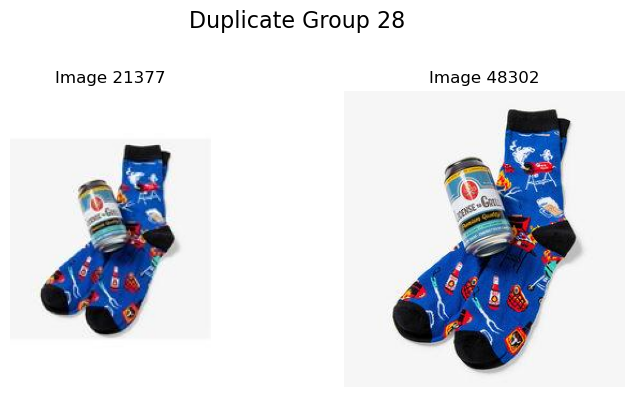

In [14]:
import pickle

# checkpoint_file = r"C:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5B Testing\dsu_checkpoints_4\dsu_checkpoint_14000_28262.pkl"
# checkpoint_file = r"C:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5B Testing\dsu_checkpoints_5\dsu_checkpoint_28000_56703.pkl"

checkpoint_file = r"C:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5B Testing\0000_dsu_checkpoints_1\dsu_checkpoint_11000_21511.pkl"

with open(checkpoint_file, "rb") as f:
    dsu = pickle.load(f)['dsu']

image_dir = r"clip_embeddings_resumable_symlink/downloaded_images/0000"
show_duplicate_groups(dsu.get_groups(), image_dir, max_groups=30)

#### Working Donwload Image Logic with Continuation & Retry Failed Logic

In [1]:
import pandas as pd
from pathlib import Path
import asyncio
import aiohttp
from aiohttp import ClientTimeout
from PIL import Image
from io import BytesIO
from tqdm import tqdm

async def fetch_and_save(session, image_id, url, download_dir):
    """Fetch a single image and save it to disk. Returns None if success, or (image_id, url, error) if failure."""
    image_path = download_dir / f"{image_id}.jpg"
    if image_path.exists():
        return None  # skip already downloaded

    try:
        async with session.get(url) as response:
            response.raise_for_status()
            content = await response.read()
            image = Image.open(BytesIO(content)).convert("RGB")
            image.save(image_path)
        return None
    except Exception as e:
        return (image_id, url, str(e))


async def download_images(parquet_path, download_root="./image_cache", image_name_column=None,
                          batch_size=500, concurrent_requests=128, retry_failed_downloads=False):
    """
    Download images from a Parquet file in batches, organized by Parquet filename.
    Resumes strictly from the highest existing image. Only retries missing images if retry_failed_downloads=True.
    """
    df = pd.read_parquet(parquet_path)
    print(f"Total rows loaded from {parquet_path}: {len(df)}")

    # Determine the column to use for image filenames
    if image_name_column is None:
        image_name_column = 'row_index'
        df = df.reset_index().rename(columns={'index': 'row_index'})

    # Create download directory based on parquet file name
    parquet_name = Path(parquet_path).stem
    download_dir = Path(download_root) / parquet_name
    download_dir.mkdir(parents=True, exist_ok=True)
    print(f"Images will be saved to: {download_dir}")

    # Identify existing images
    existing_images = {int(p.stem) for p in download_dir.glob("*.jpg") if p.stem.isdigit()}

    if existing_images:
        max_existing = max(existing_images)
        print(f"{len(existing_images)} images already exist. Resuming from {max_existing + 1}")
    else:
        max_existing = -1
        print("No existing images found. Starting from the beginning.")

    # Filter dataframe based on continuation logic
    if retry_failed_downloads:
        # Download all images not yet present
        df_to_download = df[~df[image_name_column].isin(existing_images)].reset_index(drop=True)
    else:
        # Strict continuation from last downloaded image
        df_to_download = df[df[image_name_column] > max_existing].reset_index(drop=True)

    print(f"{len(df_to_download)} images to download in this session.")

    failures = []
    timeout = ClientTimeout(total=15)
    connector = aiohttp.TCPConnector(limit=concurrent_requests)

    async with aiohttp.ClientSession(timeout=timeout, connector=connector) as session:
        for batch_start in range(0, len(df_to_download), batch_size):
            batch_end = min(batch_start + batch_size, len(df_to_download))
            batch_rows = [(row[image_name_column], row["url"]) 
                          for _, row in df_to_download.iloc[batch_start:batch_end].iterrows()]
            if not batch_rows:
                continue

            tasks = [fetch_and_save(session, img_id, url, download_dir) for img_id, url in batch_rows]

            for f in tqdm(asyncio.as_completed(tasks), total=len(tasks),
                          desc=f"Downloading batch {batch_start}-{batch_end}"):
                result = await f
                if result is not None:
                    failures.append(result)

    print(f"Finished downloading. Total failures: {len(failures)}")
    return failures

In [2]:
parquet_file = r"dataset/relaion2B-en-research-safe/0000.parquet"

failures = await download_images(
    parquet_file,
    download_root="./clip_embeddings_resumable_symlink/downloaded_images",
    image_name_column = None,
    batch_size=500,
    concurrent_requests=500,
    retry_failed_downloads = False
)

Total rows loaded from dataset/relaion2B-en-research-safe/0000.parquet: 16388209
Images will be saved to: clip_embeddings_resumable_symlink\downloaded_images\0000
No existing images found. Starting from the beginning.
16388209 images to download in this session.


  warnings.warn(
  warnings.warn(str(msg))
  warnings.warn(str(msg))


CancelledError: 